# 🎓 Student Performance Prediction & At-Risk Identification System

### Machine Learning-Based Academic Early Warning System

**Objective:**  
To predict student academic performance and identify students who may be academically at risk using machine learning techniques.

### Final Models

- **Grade Prediction:** Gradient Boosting
- **At-Risk Prediction:** Random Forest
- **At-Risk Threshold:** 0.60

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Student_performance_10k.csv")

df.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [3]:
df.head(10)

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C
5,std-06,male,group B,high school,1.0,0.0,40,49.0,69.0,48.0,206.0,C
6,std-07,NaN,group C,some college,0.0,0.0,34,48.0,84.0,73.0,239.0,C
7,std-08,male,group B,associate's degree,1.0,1.0,25,80.0,34.0,17.0,156.0,D
8,std-09,male,group C,NaN,1.0,1.0,28,79.0,100.0,76.0,283.0,B
9,std-10,male,group C,some high school,NaN,0.0,71,22.0,85.0,39.0,217.0,C


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 10000
Number of Columns: 12


In [5]:
df.columns

Index(['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education',
       'lunch', 'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'total_score', 'grade'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       9982 non-null   object 
 2   race_ethnicity               9977 non-null   object 
 3   parental_level_of_education  9978 non-null   object 
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   object 
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   object 
dtypes: float64(6), object(6)
memory usage: 937.6+ KB


In [7]:
df.describe()

,lunch,test_preparation_course,reading_score,writing_score,science_score,total_score
count,9976.000000,9977.000000,9975.000000,9976.000000,9977.000000,9981.000000
mean,0.644246,0.388694,70.125915,71.415798,66.063045,264.740908
std,0.478765,0.487478,19.026245,18.245360,19.324331,42.304858
min,0.000000,0.000000,17.000000,10.000000,9.000000,89.000000
25%,0.000000,0.000000,57.000000,59.000000,53.000000,237.000000
50%,1.000000,0.000000,71.000000,72.500000,67.000000,268.000000
75%,1.000000,1.000000,85.000000,85.000000,81.000000,294.000000
max,1.000000,1.000000,100.000000,100.000000,100.000000,383.000000


In [8]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 roll_no
roll_no
std-01       1
std-02       1
std-03       1
std-04       1
std-05       1
            ..
std-9996     1
std-9997     1
std-9998     1
std-9999     1
std-10000    1
Name: count, Length: 10000, dtype: int64

 gender
gender
female    4983
male      4982
NaN         18
Girl        10
Boy          6
\tmale       1
Name: count, dtype: int64

 race_ethnicity
race_ethnicity
group C      2921
group D      2566
group B      1899
group E      1509
group A      1062
NaN            23
D               6
group C\n       4
E               4
C               3
A               2
B               1
Name: count, dtype: int64

 parental_level_of_education
parental_level_of_education
some college          2272
high school           1987
associate's degree    1905
some high school      1742
bachelor's degree     1361
master's degree        711
NaN                     22
Name: count, dtype: int64

 math_score
math_score
27      233
58      194
100     185
64      180
51      178
       ... 
7

In [9]:
missing_values = df.isnull().sum()

print(missing_values)

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     24
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64


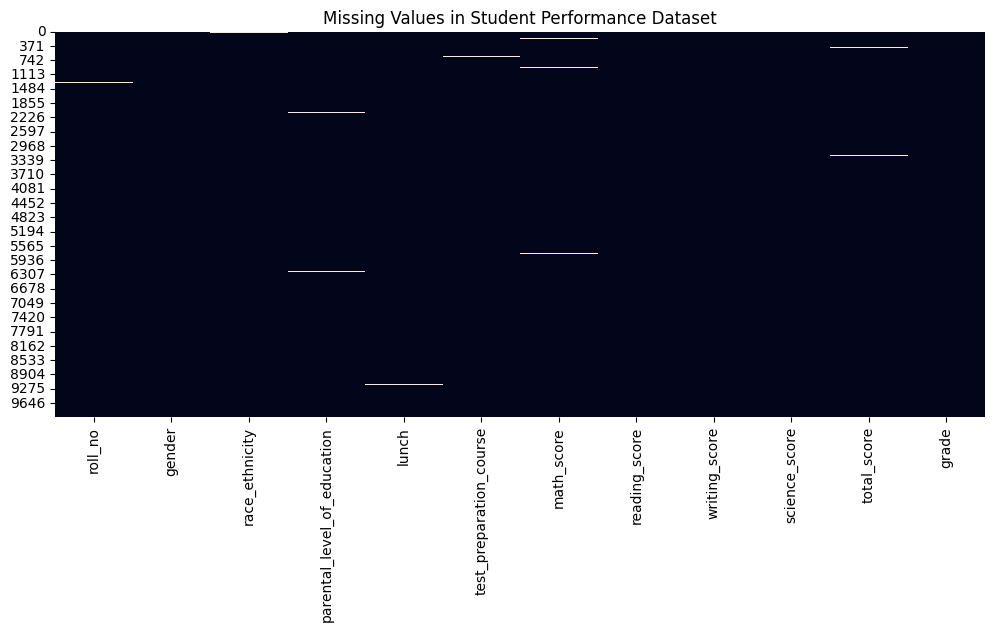

In [10]:
plt.figure(figsize=(12, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Student Performance Dataset")
plt.show()

In [11]:
print(df['math_score'].value_counts(dropna=False).head(20))

math_score
27     233
58     194
100    185
64     180
51     178
67     176
60     174
61     174
63     173
62     171
69     170
65     168
56     168
59     167
57     166
72     165
49     164
50     164
70     160
54     160
Name: count, dtype: int64


In [12]:
print(df['lunch'].value_counts(dropna=False))

lunch
1.0    6427
0.0    3549
NaN      24
Name: count, dtype: int64


In [13]:
print(df['test_preparation_course'].value_counts(dropna=False))

test_preparation_course
0.0    6099
1.0    3878
NaN      23
Name: count, dtype: int64


In [14]:
df['math_score'] = pd.to_numeric(df['math_score'], errors='coerce')

df['lunch'] = pd.to_numeric(df['lunch'], errors='coerce')

df['test_preparation_course'] = pd.to_numeric(
    df['test_preparation_course'], 
    errors='coerce'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       9982 non-null   object 
 2   race_ethnicity               9977 non-null   object 
 3   parental_level_of_education  9978 non-null   object 
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9975 non-null   float64
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   object 
dtypes: float64(7), object(5)
memory usage: 937.6+ KB


In [15]:
df.isnull().sum()

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     25
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64

In [16]:
numeric_columns = [
    'math_score',
    'reading_score',
    'writing_score',
    'science_score',
    'total_score'
]

categorical_columns = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education'
]

In [17]:
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [18]:
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df['lunch'] = df['lunch'].fillna(df['lunch'].mode()[0])

df['test_preparation_course'] = df['test_preparation_course'].fillna(
    df['test_preparation_course'].mode()[0]
)

In [20]:
df = df.dropna(subset=['grade'])

In [21]:
df.isnull().sum()

roll_no                        1
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
science_score                  0
total_score                    0
grade                          0
dtype: int64

In [22]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [23]:
df.shape

(9997, 12)

In [24]:
print(df['grade'].value_counts())

grade
B       5659
C       2701
A        904
D        671
Fail      62
Name: count, dtype: int64


In [25]:
print(df['grade'].unique())

['C' 'A' 'B' 'D' 'Fail']


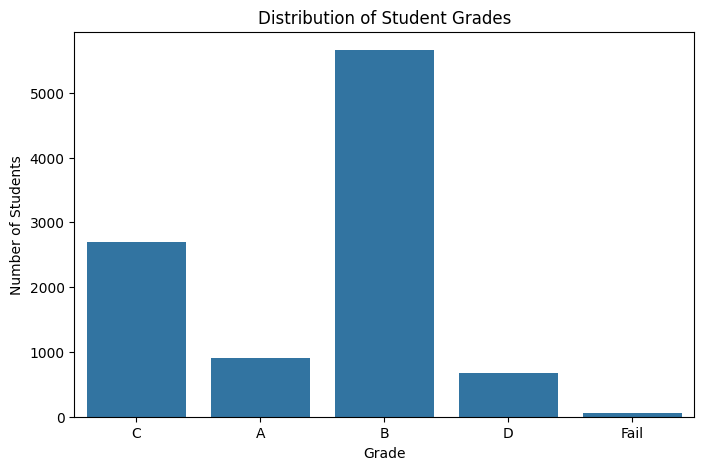

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='grade')

plt.title('Distribution of Student Grades')
plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.show()

EDA 

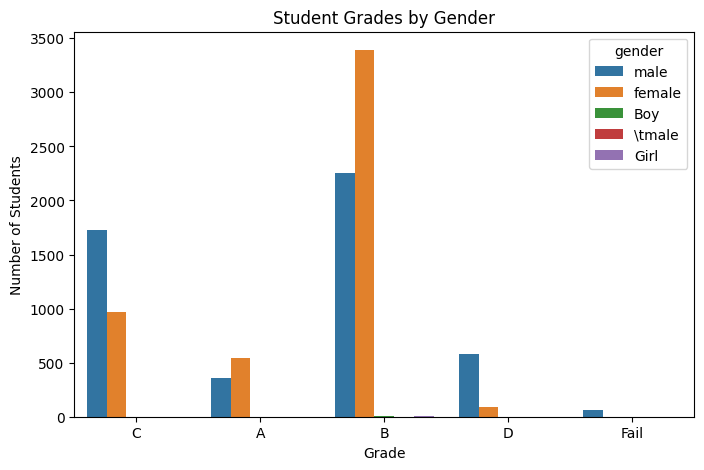

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='grade', hue='gender')

plt.title('Student Grades by Gender')
plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.show()

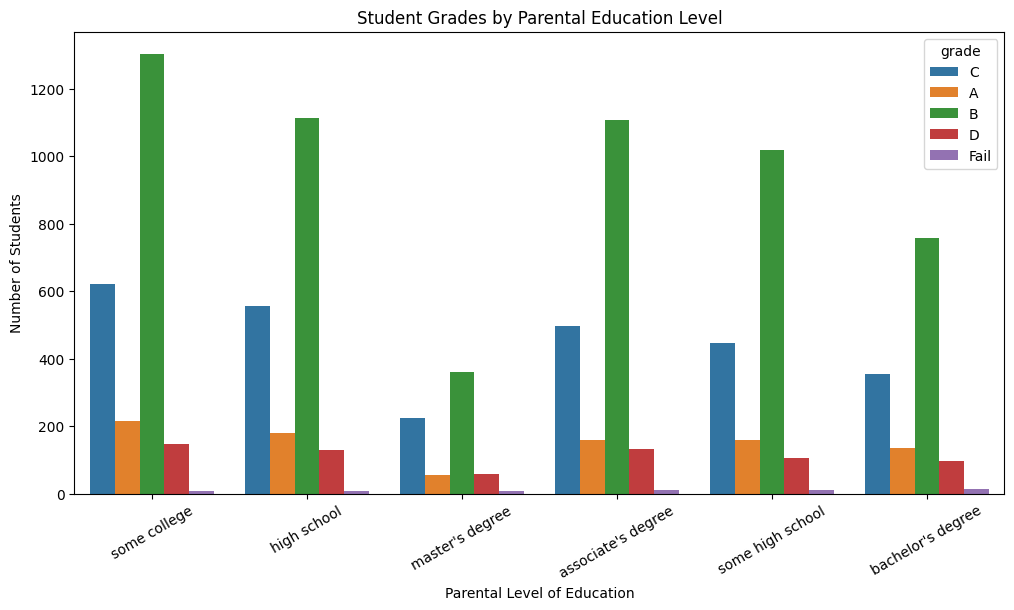

In [28]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='parental_level_of_education',
    hue='grade'
)

plt.title('Student Grades by Parental Education Level')
plt.xlabel('Parental Level of Education')
plt.ylabel('Number of Students')

plt.xticks(rotation=30)

plt.show()

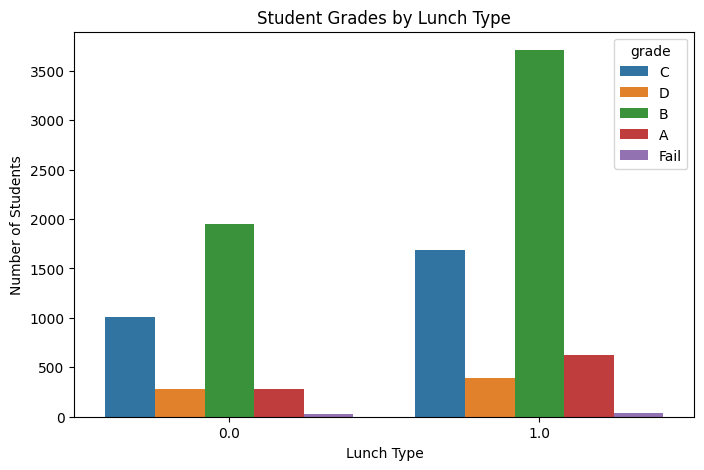

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='lunch', hue='grade')

plt.title('Student Grades by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Number of Students')

plt.show()

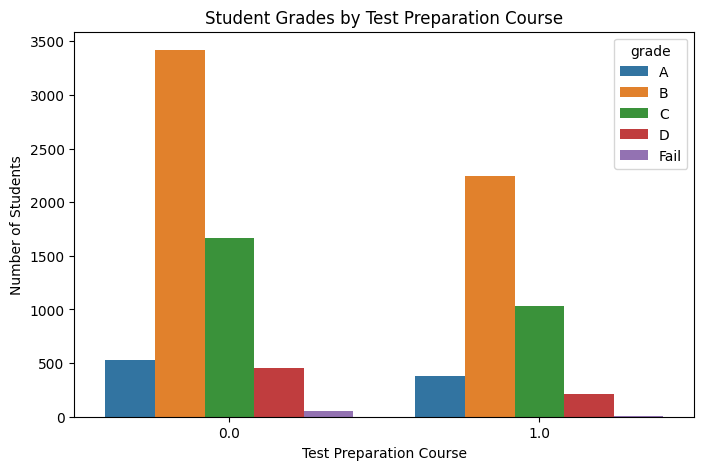

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='test_preparation_course', hue='grade')

plt.title('Student Grades by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Number of Students')

plt.show()

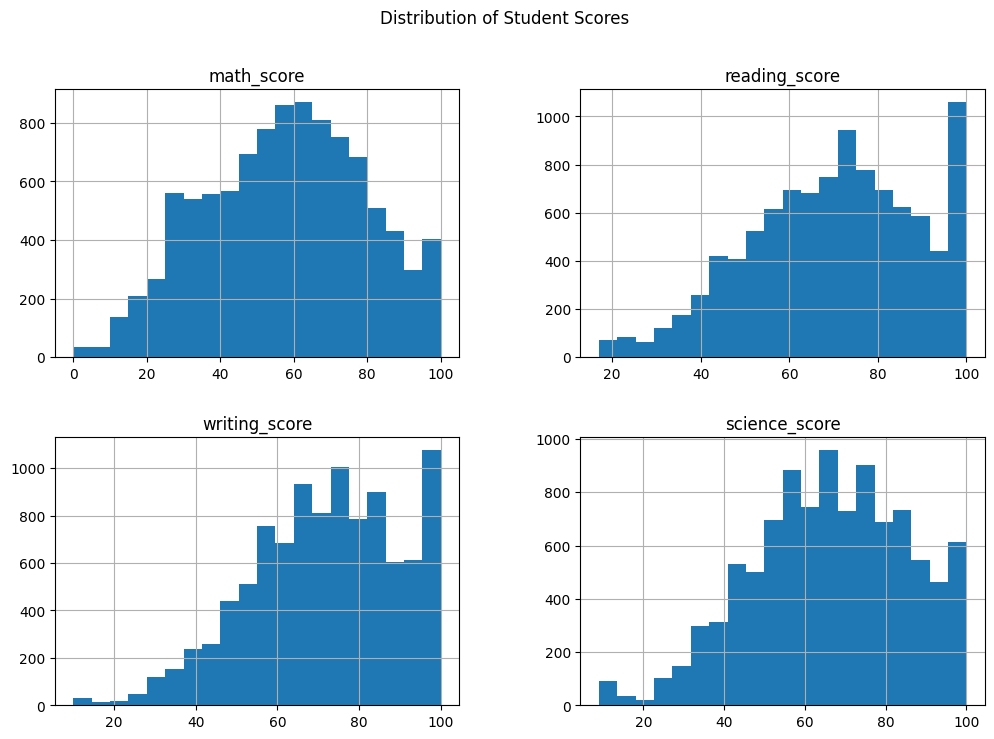

In [31]:
score_columns = [
    'math_score',
    'reading_score',
    'writing_score',
    'science_score'
]

df[score_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribution of Student Scores')

plt.show()

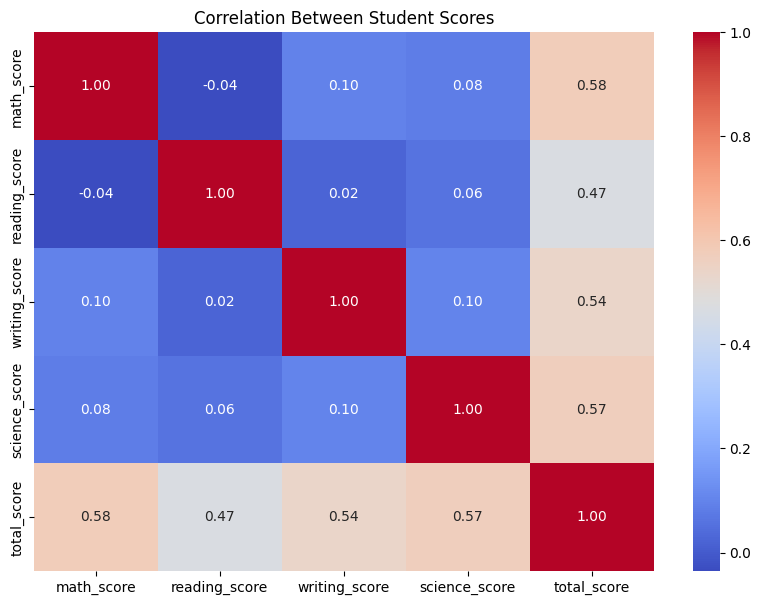

In [32]:
plt.figure(figsize=(10, 7))

correlation = df[
    ['math_score',
     'reading_score',
     'writing_score',
     'science_score',
     'total_score']
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Student Scores')

plt.show()

In [33]:
X = df[
    [
        'gender',
        'race_ethnicity',
        'parental_level_of_education',
        'lunch',
        'test_preparation_course'
    ]
]

y = df['grade']

In [34]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
  gender race_ethnicity parental_level_of_education  lunch  \
0   male        group D                some college    1.0   
1   male        group B                 high school    1.0   
2   male        group C             master's degree    1.0   
3   male        group D                some college    1.0   
4   male        group C                some college    0.0   

   test_preparation_course  
0                      1.0  
1                      0.0  
2                      0.0  
3                      1.0  
4                      1.0  

Target:
0    C
1    A
2    B
3    D
4    C
Name: grade, dtype: object


In [35]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       9997 non-null   object 
 1   race_ethnicity               9997 non-null   object 
 2   parental_level_of_education  9997 non-null   object 
 3   lunch                        9997 non-null   float64
 4   test_preparation_course      9997 non-null   float64
dtypes: float64(2), object(3)
memory usage: 468.6+ KB


In [36]:
X = pd.get_dummies(
    X,
    columns=[
        'gender',
        'race_ethnicity',
        'parental_level_of_education'
    ],
    drop_first=True
)

In [37]:
X.head()

,lunch,test_preparation_course,gender_Girl,gender_\tmale,gender_female,gender_male,race_ethnicity_B,race_ethnicity_C,race_ethnicity_D,race_ethnicity_E,...,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group C\n,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school
0,1.0,1.0,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,1.0,0.0,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
2,1.0,0.0,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,1.0,1.0,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.0,1.0,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False


In [38]:
X.shape

(9997, 21)

In [39]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Grade Mapping:")

for label, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(label, "=", encoded)

Grade Mapping:
A = 0
B = 1
C = 2
D = 3
Fail = 4


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [41]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7997, 21)
Testing data: (2000, 21)


In [42]:
print("Training Class Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Class Distribution:")
print(pd.Series(y_test).value_counts())

Training Class Distribution:
1    4527
2    2161
0     723
3     537
4      49
Name: count, dtype: int64

Testing Class Distribution:
1    1132
2     540
0     181
3     134
4      13
Name: count, dtype: int64


In [43]:
stratify=y_encoded

In [44]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [45]:
y_pred_logistic = logistic_model.predict(X_test)

print(y_pred_logistic[:20])

[0 0 1 0 4 1 1 1 0 0 3 4 0 0 1 4 0 1 4 1]


In [46]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      round(accuracy_logistic * 100, 2), "%")

Logistic Regression Accuracy: 24.9 %


In [47]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.12      0.29      0.16       181
           B       0.68      0.32      0.44      1132
           C       0.26      0.03      0.05       540
           D       0.12      0.48      0.19       134
        Fail       0.01      0.38      0.02        13

    accuracy                           0.25      2000
   macro avg       0.24      0.30      0.17      2000
weighted avg       0.47      0.25      0.29      2000



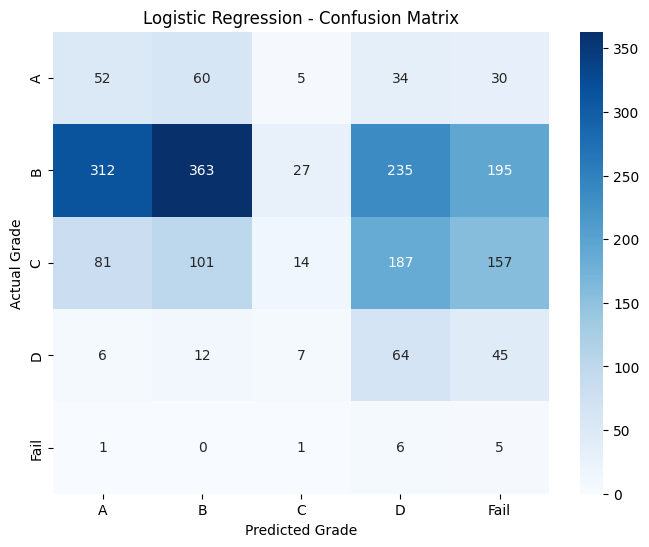

In [48]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')

plt.show()

In [49]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=5
)

decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [50]:
y_pred_tree = decision_tree.predict(X_test)

In [51]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      round(accuracy_tree * 100, 2), "%")

Decision Tree Accuracy: 20.4 %


In [52]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=8
)

random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [53]:
y_pred_rf = random_forest.predict(X_test)

In [54]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      round(accuracy_rf * 100, 2), "%")

Random Forest Accuracy: 28.95 %


In [55]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.08      0.17      0.11       181
           B       0.66      0.38      0.48      1132
           C       0.33      0.12      0.18       540
           D       0.11      0.40      0.17       134
        Fail       0.01      0.23      0.02        13

    accuracy                           0.29      2000
   macro avg       0.24      0.26      0.19      2000
weighted avg       0.48      0.29      0.34      2000



In [56]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.08      0.17      0.11       181
           B       0.66      0.38      0.48      1132
           C       0.33      0.12      0.18       540
           D       0.11      0.40      0.17       134
        Fail       0.01      0.23      0.02        13

    accuracy                           0.29      2000
   macro avg       0.24      0.26      0.19      2000
weighted avg       0.48      0.29      0.34      2000



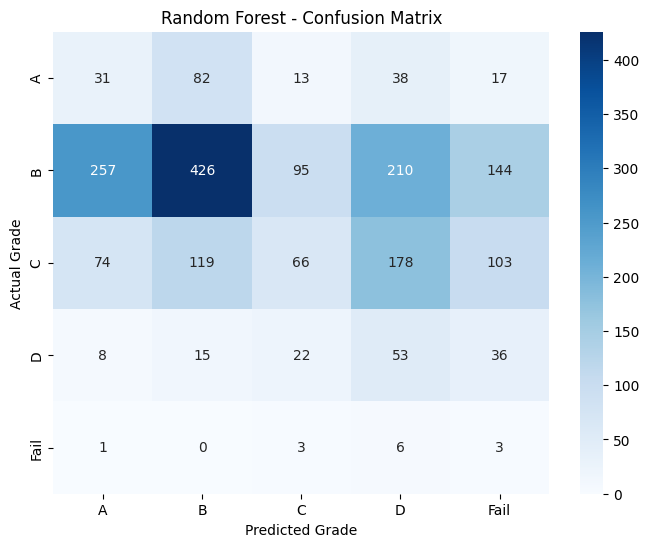

In [57]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')

plt.show()

In [58]:
gradient_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [59]:
y_pred_gradient = gradient_model.predict(X_test)

In [60]:
accuracy_gradient = accuracy_score(
    y_test,
    y_pred_gradient
)

print(
    "Gradient Boosting Accuracy:",
    round(accuracy_gradient * 100, 2),
    "%"
)

Gradient Boosting Accuracy: 56.35 %


In [61]:
print(
    classification_report(
        y_test,
        y_pred_gradient,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.00      0.00      0.00       181
           B       0.57      0.97      0.72      1132
           C       0.39      0.04      0.08       540
           D       0.00      0.00      0.00       134
        Fail       0.00      0.00      0.00        13

    accuracy                           0.56      2000
   macro avg       0.19      0.20      0.16      2000
weighted avg       0.43      0.56      0.43      2000



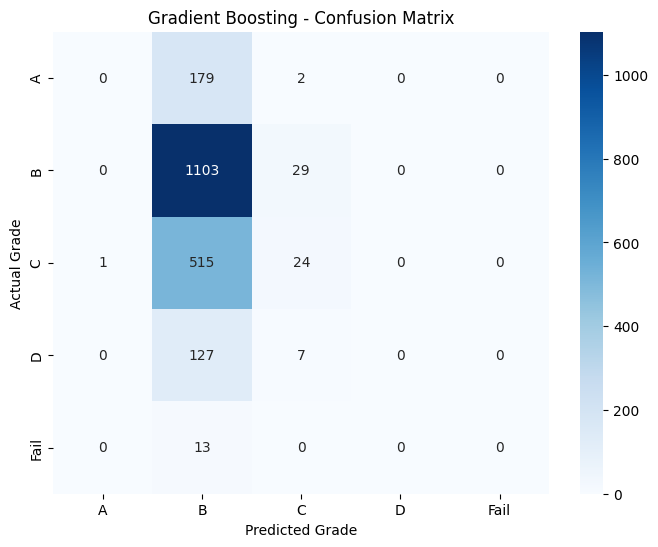

In [62]:
cm_gradient = confusion_matrix(
    y_test,
    y_pred_gradient
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_gradient,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted Grade')
plt.ylabel('Actual Grade')

plt.show()

In [63]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_gradient
    ]
})

model_results['Accuracy (%)'] = (
    model_results['Accuracy'] * 100
).round(2)

model_results = model_results.drop(
    columns=['Accuracy']
)

model_results

,Model,Accuracy (%)
0,Logistic Regression,24.90
1,Decision Tree,20.40
2,Random Forest,28.95
3,Gradient Boosting,56.35


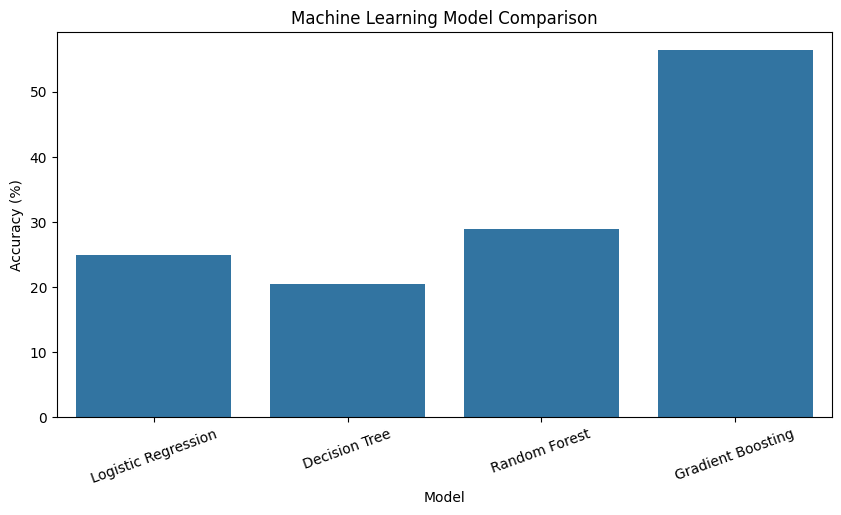

In [64]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x='Model',
    y='Accuracy (%)'
)

plt.title('Machine Learning Model Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

plt.xticks(rotation=20)

plt.show()

In [65]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gradient_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
5,gender_male,0.402974
4,gender_female,0.353699
1,test_preparation_course,0.035706
0,lunch,0.031097
18,parental_level_of_education_master's degree,0.022197
15,race_ethnicity_group E,0.020662
17,parental_level_of_education_high school,0.018248
10,race_ethnicity_group A,0.016492
19,parental_level_of_education_some college,0.013938
16,parental_level_of_education_bachelor's degree,0.012170


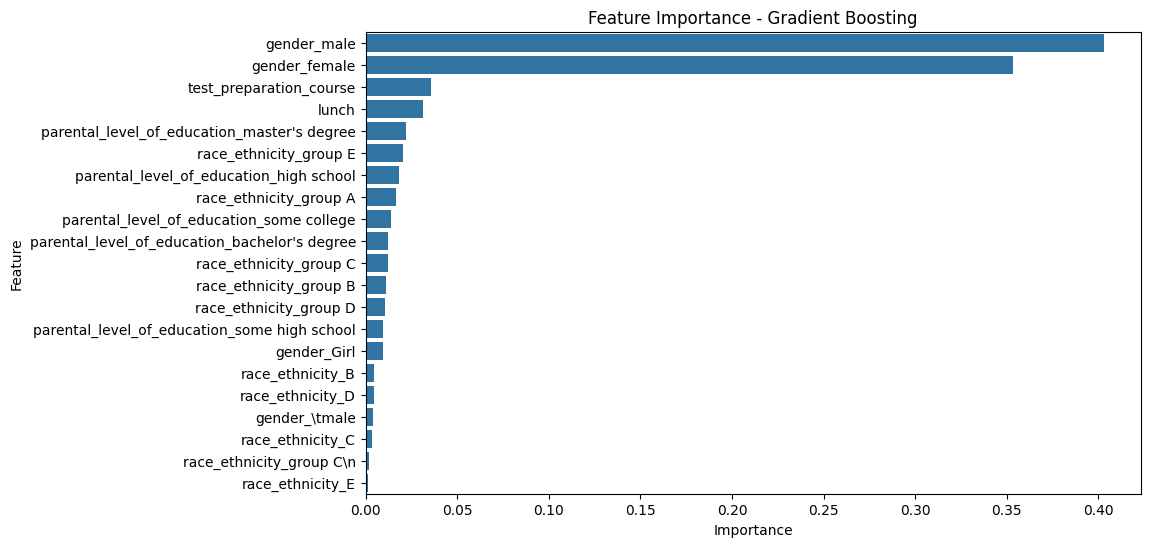

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Gradient Boosting')

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [67]:
df['at_risk'] = df['grade'].apply(
    lambda x: 1 if x in ['D', 'Fail'] else 0
)

In [68]:
print(df['at_risk'].value_counts())

at_risk
0    9264
1     733
Name: count, dtype: int64


In [69]:
print(
    df['at_risk']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

at_risk
0    92.67
1     7.33
Name: proportion, dtype: float64


In [70]:
X_risk = df[
    [
        'gender',
        'race_ethnicity',
        'parental_level_of_education',
        'lunch',
        'test_preparation_course'
    ]
]

y_risk = df['at_risk']

In [71]:
print("Features:")
print(X_risk.head())

print("\nTarget:")
print(y_risk.head())

Features:
  gender race_ethnicity parental_level_of_education  lunch  \
0   male        group D                some college    1.0   
1   male        group B                 high school    1.0   
2   male        group C             master's degree    1.0   
3   male        group D                some college    1.0   
4   male        group C                some college    0.0   

   test_preparation_course  
0                      1.0  
1                      0.0  
2                      0.0  
3                      1.0  
4                      1.0  

Target:
0    0
1    0
2    0
3    1
4    0
Name: at_risk, dtype: int64


In [72]:
X_risk = pd.get_dummies(
    X_risk,
    columns=[
        'gender',
        'race_ethnicity',
        'parental_level_of_education'
    ],
    drop_first=True
)

In [73]:
X_risk.head()

,lunch,test_preparation_course,gender_Girl,gender_\tmale,gender_female,gender_male,race_ethnicity_B,race_ethnicity_C,race_ethnicity_D,race_ethnicity_E,...,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group C\n,race_ethnicity_group D,race_ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school
0,1.0,1.0,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,1.0,0.0,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
2,1.0,0.0,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,1.0,1.0,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.0,1.0,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False


In [74]:
X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.20,
    random_state=42,
    stratify=y_risk
)

In [75]:
print("Training data:", X_train_risk.shape)
print("Testing data:", X_test_risk.shape)

print("\nTraining target distribution:")
print(y_train_risk.value_counts())

print("\nTesting target distribution:")
print(y_test_risk.value_counts())

Training data: (7997, 21)
Testing data: (2000, 21)

Training target distribution:
at_risk
0    7411
1     586
Name: count, dtype: int64

Testing target distribution:
at_risk
0    1853
1     147
Name: count, dtype: int64


In [76]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_risk
)

In [77]:
risk_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

risk_model.fit(
    X_train_risk,
    y_train_risk,
    sample_weight=sample_weights
)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [78]:
y_pred_risk = risk_model.predict(X_test_risk)

In [79]:
risk_accuracy = accuracy_score(
    y_test_risk,
    y_pred_risk
)

print(
    "At-Risk Model Accuracy:",
    round(risk_accuracy * 100, 2),
    "%"
)

At-Risk Model Accuracy: 55.05 %


In [80]:
print(
    classification_report(
        y_test_risk,
        y_pred_risk,
        target_names=[
            'Not At Risk',
            'At Risk'
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not At Risk       0.98      0.53      0.68      1853
     At Risk       0.13      0.87      0.22       147

    accuracy                           0.55      2000
   macro avg       0.55      0.70      0.45      2000
weighted avg       0.92      0.55      0.65      2000



Confusion Matrix:
[[ 92  89   0   0   0]
 [564 568   0   0   0]
 [261 279   0   0   0]
 [ 72  62   0   0   0]
 [  3  10   0   0   0]]

Class labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


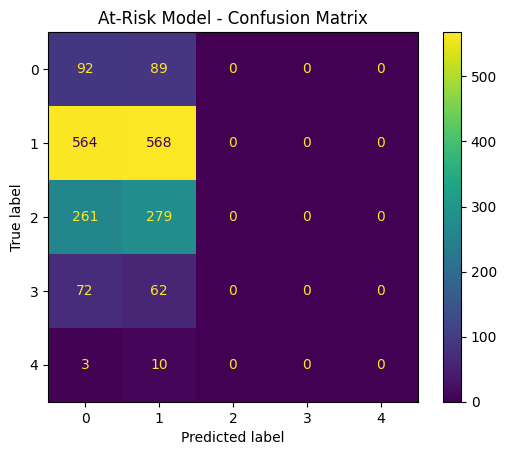

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_risk)

print("Confusion Matrix:")
print(cm)

# Get the actual class labels
class_labels = sorted(set(y_test))

print("\nClass labels:")
print(class_labels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

disp.plot()
plt.title("At-Risk Model - Confusion Matrix")
plt.show()

In [82]:
# Check available prediction-related variables
[name for name in globals() if 'pred' in name.lower()]

['y_pred_logistic',
 'y_pred_tree',
 'y_pred_rf',
 'y_pred_gradient',
 'y_pred_risk']

In [83]:
import pandas as pd

print("Actual class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nPredicted class distribution:")
print(pd.Series(y_pred_risk).value_counts().sort_index())

Actual class distribution:
0     181
1    1132
2     540
3     134
4      13
Name: count, dtype: int64

Predicted class distribution:
0     992
1    1008
Name: count, dtype: int64


In [84]:
print("Unique actual classes:", sorted(pd.Series(y_test).unique()))
print("Unique predicted classes:", sorted(pd.Series(y_pred_risk).unique()))

Unique actual classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique predicted classes: [np.int64(0), np.int64(1)]


In [85]:
# Find variables related to the At-Risk model
[name for name in globals() if any(
    word in name.lower()
    for word in ['risk', 'target', 'y_test', 'y_train']
)]

['y_train',
 'y_test',
 'X_risk',
 'y_risk',
 'X_train_risk',
 'X_test_risk',
 'y_train_risk',
 'y_test_risk',
 'risk_model',
 'y_pred_risk',
 'risk_accuracy']

In [86]:
print("y_test shape:", y_test.shape)
print("y_pred_risk shape:", y_pred_risk.shape)

print("\ny_test unique values:")
print(pd.Series(y_test).value_counts().sort_index())

print("\ny_pred_risk unique values:")
print(pd.Series(y_pred_risk).value_counts().sort_index())

y_test shape: (2000,)
y_pred_risk shape: (2000,)

y_test unique values:
0     181
1    1132
2     540
3     134
4      13
Name: count, dtype: int64

y_pred_risk unique values:
0     992
1    1008
Name: count, dtype: int64


In [87]:
print("y_test_risk shape:", y_test_risk.shape)
print("y_pred_risk shape:", y_pred_risk.shape)

print("\nActual At-Risk distribution:")
print(pd.Series(y_test_risk).value_counts().sort_index())

print("\nPredicted At-Risk distribution:")
print(pd.Series(y_pred_risk).value_counts().sort_index())

print("\nUnique actual classes:", sorted(pd.Series(y_test_risk).unique()))
print("Unique predicted classes:", sorted(pd.Series(y_pred_risk).unique()))

y_test_risk shape: (2000,)
y_pred_risk shape: (2000,)

Actual At-Risk distribution:
at_risk
0    1853
1     147
Name: count, dtype: int64

Predicted At-Risk distribution:
0     992
1    1008
Name: count, dtype: int64

Unique actual classes: [np.int64(0), np.int64(1)]
Unique predicted classes: [np.int64(0), np.int64(1)]


At-Risk Confusion Matrix:
[[973 880]
 [ 19 128]]


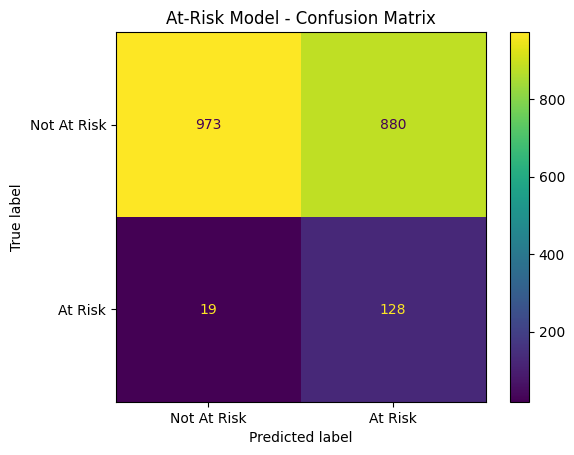

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Correct confusion matrix for At-Risk model
cm_risk = confusion_matrix(y_test_risk, y_pred_risk)

print("At-Risk Confusion Matrix:")
print(cm_risk)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_risk,
    display_labels=["Not At Risk", "At Risk"]
)

disp.plot()
plt.title("At-Risk Model - Confusion Matrix")
plt.show()

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Extract confusion matrix values
tn, fp, fn, tp = cm_risk.ravel()

# Calculate metrics
accuracy = accuracy_score(y_test_risk, y_pred_risk)
precision = precision_score(y_test_risk, y_pred_risk)
recall = recall_score(y_test_risk, y_pred_risk)
f1 = f1_score(y_test_risk, y_pred_risk)

# Specificity = True Negative Rate
specificity = tn / (tn + fp)

print("At-Risk Model Performance")
print("-" * 35)
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")
print("-" * 35)
print(f"Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision   : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall      : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score    : {f1:.4f} ({f1*100:.2f}%)")
print(f"Specificity : {specificity:.4f} ({specificity*100:.2f}%)")

At-Risk Model Performance
-----------------------------------
True Negatives : 973
False Positives: 880
False Negatives: 19
True Positives : 128
-----------------------------------
Accuracy    : 0.5505 (55.05%)
Precision   : 0.1270 (12.70%)
Recall      : 0.8707 (87.07%)
F1-Score    : 0.2216 (22.16%)
Specificity : 0.5251 (52.51%)


In [90]:
# Get probability of the At-Risk class
y_prob_risk = risk_model.predict_proba(X_test_risk)[:, 1]

print("Minimum probability:", y_prob_risk.min())
print("Maximum probability:", y_prob_risk.max())
print("Mean probability:", y_prob_risk.mean())

Minimum probability: 0.048795480895622884
Maximum probability: 0.8048820669809036
Mean probability: 0.4182970659121264


In [91]:
import numpy as np

print("\nProbability distribution:")
print("Below 0.1 :", np.sum(y_prob_risk < 0.1))
print("0.1 - 0.2  :", np.sum((y_prob_risk >= 0.1) & (y_prob_risk < 0.2)))
print("0.2 - 0.3  :", np.sum((y_prob_risk >= 0.2) & (y_prob_risk < 0.3)))
print("0.3 - 0.4  :", np.sum((y_prob_risk >= 0.3) & (y_prob_risk < 0.4)))
print("0.4 - 0.5  :", np.sum((y_prob_risk >= 0.4) & (y_prob_risk < 0.5)))
print("0.5 - 0.6  :", np.sum((y_prob_risk >= 0.5) & (y_prob_risk < 0.6)))
print("0.6 - 0.7  :", np.sum((y_prob_risk >= 0.6) & (y_prob_risk < 0.7)))
print("0.7 - 0.8  :", np.sum((y_prob_risk >= 0.7) & (y_prob_risk < 0.8)))
print("0.8 - 0.9  :", np.sum((y_prob_risk >= 0.8) & (y_prob_risk < 0.9)))
print("0.9 - 1.0  :", np.sum(y_prob_risk >= 0.9))


Probability distribution:
Below 0.1 : 42
0.1 - 0.2  : 442
0.2 - 0.3  : 468
0.3 - 0.4  : 11
0.4 - 0.5  : 29
0.5 - 0.6  : 261
0.6 - 0.7  : 586
0.7 - 0.8  : 147
0.8 - 0.9  : 14
0.9 - 1.0  : 0


In [92]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_risk >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_risk, y_pred_threshold),
        "Precision": precision_score(y_test_risk, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test_risk, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test_risk, y_pred_threshold, zero_division=0),
        "Predicted At Risk": y_pred_threshold.sum()
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.round(4).to_string(index=False))

 Threshold  Accuracy  Precision  Recall  F1 Score  Predicted At Risk
      0.10    0.0935     0.0746  0.9932    0.1387               1958
      0.15    0.1790     0.0798  0.9660    0.1475               1779
      0.20    0.3035     0.0891  0.9184    0.1624               1516
      0.25    0.5100     0.1182  0.8776    0.2084               1091
      0.30    0.5315     0.1231  0.8776    0.2159               1048
      0.35    0.5370     0.1244  0.8776    0.2179               1037
      0.40    0.5370     0.1244  0.8776    0.2179               1037
      0.45    0.5460     0.1266  0.8776    0.2213               1019
      0.50    0.5505     0.1270  0.8707    0.2216               1008
      0.55    0.5905     0.1316  0.8163    0.2266                912
      0.60    0.6570     0.1392  0.7075    0.2327                747
      0.65    0.7500     0.1477  0.5034    0.2284                501
      0.70    0.8660     0.1242  0.1361    0.1299                161
      0.75    0.9125     0.0882  0

In [93]:
from sklearn.metrics import classification_report, confusion_matrix

# Best threshold based on F1-score
best_threshold = 0.60

y_pred_risk_060 = (y_prob_risk >= best_threshold).astype(int)

print("Classification Report - Threshold 0.60")
print("=" * 50)

print(classification_report(
    y_test_risk,
    y_pred_risk_060,
    target_names=["Not At Risk", "At Risk"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_risk, y_pred_risk_060))

Classification Report - Threshold 0.60
              precision    recall  f1-score   support

 Not At Risk       0.97      0.65      0.78      1853
     At Risk       0.14      0.71      0.23       147

    accuracy                           0.66      2000
   macro avg       0.55      0.68      0.51      2000
weighted avg       0.90      0.66      0.74      2000

Confusion Matrix:
[[1210  643]
 [  43  104]]


In [94]:
print("Training target distribution:")
print(pd.Series(y_train_risk).value_counts())

print("\nTraining target proportions:")
print(
    pd.Series(y_train_risk)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Training target distribution:
at_risk
0    7411
1     586
Name: count, dtype: int64

Training target proportions:
at_risk
0    92.67
1     7.33
Name: proportion, dtype: float64


In [95]:
print("Training samples:", len(y_train_risk))
print("Testing samples :", len(y_test_risk))

print("\nAt-Risk training samples:",
      (y_train_risk == 1).sum())

print("Not At-Risk training samples:",
      (y_train_risk == 0).sum())

Training samples: 7997
Testing samples : 2000

At-Risk training samples: 586
Not At-Risk training samples: 7411


In [96]:
print("At-Risk feature columns:")
print(X_risk.columns.tolist())

print("\nNumber of features:", X_risk.shape[1])
print("Training shape:", X_train_risk.shape)
print("Testing shape:", X_test_risk.shape)

At-Risk feature columns:
['lunch', 'test_preparation_course', 'gender_Girl', 'gender_\\tmale', 'gender_female', 'gender_male', 'race_ethnicity_B', 'race_ethnicity_C', 'race_ethnicity_D', 'race_ethnicity_E', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group C\\n', 'race_ethnicity_group D', 'race_ethnicity_group E', "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school']

Number of features: 21
Training shape: (7997, 21)
Testing shape: (2000, 21)


In [97]:
print("\nFeature data types:")
print(X_risk.dtypes)


Feature data types:
lunch                                            float64
test_preparation_course                          float64
gender_Girl                                         bool
gender_\tmale                                       bool
gender_female                                       bool
gender_male                                         bool
race_ethnicity_B                                    bool
race_ethnicity_C                                    bool
race_ethnicity_D                                    bool
race_ethnicity_E                                    bool
race_ethnicity_group A                              bool
race_ethnicity_group B                              bool
race_ethnicity_group C                              bool
race_ethnicity_group C\n                            bool
race_ethnicity_group D                              bool
race_ethnicity_group E                              bool
parental_level_of_education_bachelor's degree       bool
parental_l

In [98]:
print("All At-Risk Features:")
for i, col in enumerate(X_risk.columns, start=1):
    print(f"{i}. {repr(col)}")
    

All At-Risk Features:
1. 'lunch'
2. 'test_preparation_course'
3. 'gender_Girl'
4. 'gender_\\tmale'
5. 'gender_female'
6. 'gender_male'
7. 'race_ethnicity_B'
8. 'race_ethnicity_C'
9. 'race_ethnicity_D'
10. 'race_ethnicity_E'
11. 'race_ethnicity_group A'
12. 'race_ethnicity_group B'
13. 'race_ethnicity_group C'
14. 'race_ethnicity_group C\\n'
15. 'race_ethnicity_group D'
16. 'race_ethnicity_group E'
17. "parental_level_of_education_bachelor's degree"
18. 'parental_level_of_education_high school'
19. "parental_level_of_education_master's degree"
20. 'parental_level_of_education_some college'
21. 'parental_level_of_education_some high school'


In [99]:
print("\nDuplicate-looking columns:")
print([
    col for col in X_risk.columns
    if "gender" in col.lower() or "race" in col.lower()
])


Duplicate-looking columns:
['gender_Girl', 'gender_\\tmale', 'gender_female', 'gender_male', 'race_ethnicity_B', 'race_ethnicity_C', 'race_ethnicity_D', 'race_ethnicity_E', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group C\\n', 'race_ethnicity_group D', 'race_ethnicity_group E']


In [100]:
# Check the columns in the original dataset
print("Original dataset columns:")
print(df.columns.tolist())

Original dataset columns:
['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score', 'total_score', 'grade', 'at_risk']


In [101]:
# Inspect unique values of the categorical columns
categorical_cols = [
    col for col in df.columns
    if df[col].dtype == 'object'
]

print("Categorical columns:")
print(categorical_cols)

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())

Categorical columns:
['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education', 'grade']

roll_no:
['std-01' 'std-02' 'std-03' ... 'std-9998' 'std-9999' 'std-10000']

gender:
['male' 'female' 'Boy' '\\tmale' 'Girl']

race_ethnicity:
['group D' 'group B' 'group C' 'group E' 'group A' 'A' 'C' 'D'
 'group C\\n' 'B' 'E']

parental_level_of_education:
['some college' 'high school' "master's degree" "associate's degree"
 'some high school' "bachelor's degree"]

grade:
['C' 'A' 'B' 'D' 'Fail']


In [102]:
# Create a clean copy of the original dataset
df_clean = df.copy()

# -----------------------------
# Clean Gender
# -----------------------------
df_clean["gender"] = (
    df_clean["gender"]
    .astype(str)
    .str.strip()
    .str.replace("\\t", "", regex=False)
    .str.lower()
)

df_clean["gender"] = df_clean["gender"].replace({
    "boy": "male",
    "girl": "female"
})

# -----------------------------
# Clean Race/Ethnicity
# -----------------------------
df_clean["race_ethnicity"] = (
    df_clean["race_ethnicity"]
    .astype(str)
    .str.strip()
    .str.replace("\\n", "", regex=False)
    .str.replace("group ", "", regex=False)
    .str.upper()
)

# -----------------------------
# Check cleaned values
# -----------------------------
print("Cleaned Gender values:")
print(df_clean["gender"].value_counts())

print("\nCleaned Race/Ethnicity values:")
print(df_clean["race_ethnicity"].value_counts())

print("\nCleaned Grade values:")
print(df_clean["grade"].value_counts())

Cleaned Gender values:
gender
female    5010
male      4987
Name: count, dtype: int64

Cleaned Race/Ethnicity values:
race_ethnicity
C    2950
D    2571
B    1900
E    1512
A    1064
Name: count, dtype: int64

Cleaned Grade values:
grade
B       5659
C       2701
A        904
D        671
Fail      62
Name: count, dtype: int64


In [103]:
from sklearn.model_selection import train_test_split
import pandas as pd

# -----------------------------------------
# Create binary At-Risk target
# -----------------------------------------
df_risk_clean = df_clean.copy()

df_risk_clean["at_risk"] = df_risk_clean["grade"].apply(
    lambda x: 1 if x in ["D", "Fail"] else 0
)

# -----------------------------------------
# Select features
# -----------------------------------------
risk_features = [
    "gender",
    "race_ethnicity",
    "parental_level_of_education",
    "lunch",
    "test_preparation_course"
]

X_risk_clean = df_risk_clean[risk_features].copy()
y_risk_clean = df_risk_clean["at_risk"].copy()

# -----------------------------------------
# One-hot encode categorical variables
# -----------------------------------------
X_risk_clean = pd.get_dummies(
    X_risk_clean,
    columns=[
        "gender",
        "race_ethnicity",
        "parental_level_of_education"
    ],
    drop_first=True
)

# -----------------------------------------
# Convert boolean columns to integers
# -----------------------------------------
bool_cols = X_risk_clean.select_dtypes(include="bool").columns
X_risk_clean[bool_cols] = X_risk_clean[bool_cols].astype(int)

# -----------------------------------------
# Train-test split
# -----------------------------------------
X_train_risk_clean, X_test_risk_clean, y_train_risk_clean, y_test_risk_clean = train_test_split(
    X_risk_clean,
    y_risk_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_risk_clean
)

# -----------------------------------------
# Display results
# -----------------------------------------
print("Clean At-Risk Dataset")
print("=" * 40)

print("Total samples:", len(X_risk_clean))
print("Total features:", X_risk_clean.shape[1])

print("\nTarget distribution:")
print(y_risk_clean.value_counts())

print("\nTarget proportions:")
print(
    y_risk_clean.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTraining shape:", X_train_risk_clean.shape)
print("Testing shape :", X_test_risk_clean.shape)

print("\nFeature columns:")
print(X_risk_clean.columns.tolist())

Clean At-Risk Dataset
Total samples: 9997
Total features: 12

Target distribution:
at_risk
0    9264
1     733
Name: count, dtype: int64

Target proportions:
at_risk
0    92.67
1     7.33
Name: proportion, dtype: float64

Training shape: (7997, 12)
Testing shape : (2000, 12)

Feature columns:
['lunch', 'test_preparation_course', 'gender_male', 'race_ethnicity_B', 'race_ethnicity_C', 'race_ethnicity_D', 'race_ethnicity_E', "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school']


In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------------------
# Train improved Random Forest
# -----------------------------------------
risk_model_clean = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

risk_model_clean.fit(
    X_train_risk_clean,
    y_train_risk_clean
)

# -----------------------------------------
# Predictions
# -----------------------------------------
y_pred_risk_clean = risk_model_clean.predict(
    X_test_risk_clean
)

# -----------------------------------------
# Evaluation
# -----------------------------------------
print("Improved At-Risk Model")
print("=" * 50)

print("\nAccuracy:",
      f"{accuracy_score(y_test_risk_clean, y_pred_risk_clean) * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_risk_clean,
        y_pred_risk_clean,
        target_names=["Not At Risk", "At Risk"],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_risk_clean,
        y_pred_risk_clean
    )
)

Improved At-Risk Model

Accuracy: 62.75%

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.96      0.63      0.76      1853
     At Risk       0.12      0.65      0.20       147

    accuracy                           0.63      2000
   macro avg       0.54      0.64      0.48      2000
weighted avg       0.90      0.63      0.72      2000

Confusion Matrix:
[[1160  693]
 [  52   95]]


In [105]:
# Get probability of At-Risk class
y_prob_risk_clean = risk_model_clean.predict_proba(
    X_test_risk_clean
)[:, 1]

print("Probability statistics")
print("=" * 40)
print("Minimum probability:", y_prob_risk_clean.min())
print("Maximum probability:", y_prob_risk_clean.max())
print("Mean probability   :", y_prob_risk_clean.mean())

Probability statistics
Minimum probability: 0.0
Maximum probability: 0.8540574380405017
Mean probability   : 0.3571126233894085


In [106]:
print("\nProbability distribution:")

print("Below 0.1 :", np.sum(y_prob_risk_clean < 0.1))
print("0.1 - 0.2 :", np.sum((y_prob_risk_clean >= 0.1) & (y_prob_risk_clean < 0.2)))
print("0.2 - 0.3 :", np.sum((y_prob_risk_clean >= 0.2) & (y_prob_risk_clean < 0.3)))
print("0.3 - 0.4 :", np.sum((y_prob_risk_clean >= 0.3) & (y_prob_risk_clean < 0.4)))
print("0.4 - 0.5 :", np.sum((y_prob_risk_clean >= 0.4) & (y_prob_risk_clean < 0.5)))
print("0.5 - 0.6 :", np.sum((y_prob_risk_clean >= 0.5) & (y_prob_risk_clean < 0.6)))
print("0.6 - 0.7 :", np.sum((y_prob_risk_clean >= 0.6) & (y_prob_risk_clean < 0.7)))
print("0.7 - 0.8 :", np.sum((y_prob_risk_clean >= 0.7) & (y_prob_risk_clean < 0.8)))
print("0.8 - 0.9 :", np.sum((y_prob_risk_clean >= 0.8) & (y_prob_risk_clean < 0.9)))
print("0.9 - 1.0 :", np.sum(y_prob_risk_clean >= 0.9))


Probability distribution:
Below 0.1 : 515
0.1 - 0.2 : 127
0.2 - 0.3 : 250
0.3 - 0.4 : 168
0.4 - 0.5 : 152
0.5 - 0.6 : 312
0.6 - 0.7 : 232
0.7 - 0.8 : 229
0.8 - 0.9 : 15
0.9 - 1.0 : 0


In [107]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.81, 0.05)

results_clean = []

for threshold in thresholds:
    y_pred_threshold = (
        y_prob_risk_clean >= threshold
    ).astype(int)

    results_clean.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(
            y_test_risk_clean,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test_risk_clean,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_risk_clean,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test_risk_clean,
            y_pred_threshold,
            zero_division=0
        ),
        "Predicted At Risk": y_pred_threshold.sum()
    })

threshold_results_clean = pd.DataFrame(results_clean)

print(
    threshold_results_clean.round(4).to_string(index=False)
)

 Threshold  Accuracy  Precision  Recall  F1 Score  Predicted At Risk
      0.10    0.3190     0.0909  0.9184    0.1654               1485
      0.15    0.3550     0.0938  0.8980    0.1699               1407
      0.20    0.3795     0.0972  0.8980    0.1754               1358
      0.25    0.4520     0.1075  0.8844    0.1917               1209
      0.30    0.4975     0.1128  0.8503    0.1992               1108
      0.35    0.5325     0.1175  0.8231    0.2056               1030
      0.40    0.5695     0.1202  0.7687    0.2079                940
      0.45    0.5925     0.1170  0.6939    0.2002                872
      0.50    0.6275     0.1206  0.6463    0.2032                788
      0.55    0.6855     0.1246  0.5442    0.2028                642
      0.60    0.7475     0.1239  0.4014    0.1894                476
      0.65    0.7925     0.1298  0.3197    0.1847                362
      0.70    0.8375     0.1352  0.2245    0.1688                244
      0.75    0.8900     0.0805  0

In [108]:
# Best threshold from Step 40.23
best_threshold_clean = 0.40

# Generate final predictions at best threshold
y_pred_risk_clean_best = (
    y_prob_risk_clean >= best_threshold_clean
).astype(int)

print("Clean At-Risk Model - Threshold 0.40")
print("=" * 55)

print("\nClassification Report:")
print(
    classification_report(
        y_test_risk_clean,
        y_pred_risk_clean_best,
        target_names=["Not At Risk", "At Risk"],
        zero_division=0
    )
)

print("Confusion Matrix:")
cm_clean_best = confusion_matrix(
    y_test_risk_clean,
    y_pred_risk_clean_best
)

print(cm_clean_best)

# Extract values
tn, fp, fn, tp = cm_clean_best.ravel()

print("\nConfusion Matrix Details:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Clean At-Risk Model - Threshold 0.40

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.97      0.55      0.70      1853
     At Risk       0.12      0.77      0.21       147

    accuracy                           0.57      2000
   macro avg       0.54      0.66      0.46      2000
weighted avg       0.91      0.57      0.67      2000

Confusion Matrix:
[[1026  827]
 [  34  113]]

Confusion Matrix Details:
True Negatives : 1026
False Positives: 827
False Negatives: 34
True Positives : 113


In [109]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "At-Risk Precision",
        "At-Risk Recall",
        "At-Risk F1",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],

    "Original Model (Threshold 0.60)": [
        0.6570,
        0.1392,
        0.7075,
        0.2327,
        1210,
        643,
        43,
        104
    ],

    "Clean Balanced RF (Threshold 0.40)": [
        0.5695,
        0.1202,
        0.7687,
        0.2079,
        1026,
        827,
        34,
        113
    ]
})

print(comparison.to_string(index=False))

           Metric  Original Model (Threshold 0.60)  Clean Balanced RF (Threshold 0.40)
         Accuracy                           0.6570                              0.5695
At-Risk Precision                           0.1392                              0.1202
   At-Risk Recall                           0.7075                              0.7687
       At-Risk F1                           0.2327                              0.2079
   True Negatives                        1210.0000                           1026.0000
  False Positives                         643.0000                            827.0000
  False Negatives                          43.0000                             34.0000
   True Positives                         104.0000                            113.0000


In [110]:
print("\nBest model by At-Risk F1:")

if 0.2327 > 0.2079:
    print("Original Model - Threshold 0.60")
else:
    print("Clean Balanced Random Forest - Threshold 0.40")


Best model by At-Risk F1:
Original Model - Threshold 0.60


In [111]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the original At-Risk model
feature_importance = pd.DataFrame({
    "Feature": X_train_risk.columns,
    "Importance": risk_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("At-Risk Model Feature Importance")
print("=" * 50)
print(feature_importance.to_string(index=False))

At-Risk Model Feature Importance
                                      Feature  Importance
                                  gender_male    0.857860
                                        lunch    0.021140
                       race_ethnicity_group A    0.020776
                      test_preparation_course    0.020396
  parental_level_of_education_master's degree    0.017201
                       race_ethnicity_group B    0.011881
 parental_level_of_education_some high school    0.011753
                       race_ethnicity_group E    0.010301
     parental_level_of_education_some college    0.007280
parental_level_of_education_bachelor's degree    0.006818
                       race_ethnicity_group C    0.005520
                       race_ethnicity_group D    0.003322
      parental_level_of_education_high school    0.001819
                     race_ethnicity_group C\n    0.001791
                                gender_female    0.000987
                             race_ethni

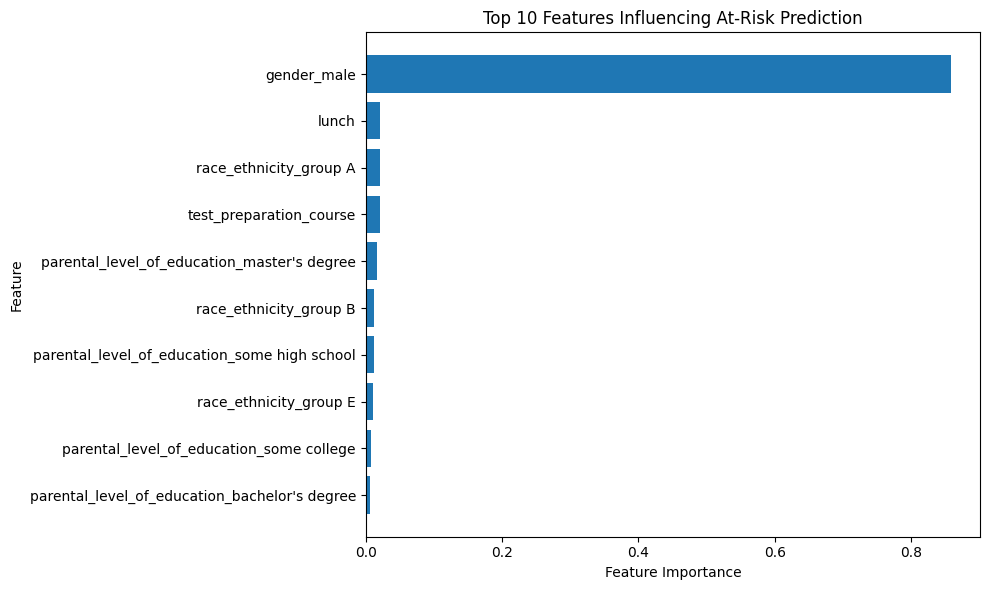

In [112]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing At-Risk Prediction")

plt.tight_layout()
plt.show()

In [113]:
# ==========================================
# 40.27 — Final At-Risk Model Configuration
# ==========================================

FINAL_RISK_THRESHOLD = 0.60

# Generate final At-Risk predictions
y_pred_final_risk = (
    y_prob_risk >= FINAL_RISK_THRESHOLD
).astype(int)

# Final confusion matrix
cm_final_risk = confusion_matrix(
    y_test_risk,
    y_pred_final_risk
)

tn, fp, fn, tp = cm_final_risk.ravel()

# Final metrics
final_accuracy = accuracy_score(
    y_test_risk,
    y_pred_final_risk
)

final_precision = precision_score(
    y_test_risk,
    y_pred_final_risk,
    zero_division=0
)

final_recall = recall_score(
    y_test_risk,
    y_pred_final_risk,
    zero_division=0
)

final_f1 = f1_score(
    y_test_risk,
    y_pred_final_risk,
    zero_division=0
)

final_specificity = tn / (tn + fp)

print("=" * 55)
print("FINAL AT-RISK MODEL")
print("=" * 55)

print(f"Threshold    : {FINAL_RISK_THRESHOLD}")
print(f"Accuracy     : {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"Precision    : {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"Recall       : {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"F1 Score     : {final_f1:.4f} ({final_f1*100:.2f}%)")
print(f"Specificity  : {final_specificity:.4f} ({final_specificity*100:.2f}%)")

print("\nConfusion Matrix:")
print(cm_final_risk)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

FINAL AT-RISK MODEL
Threshold    : 0.6
Accuracy     : 0.6570 (65.70%)
Precision    : 0.1392 (13.92%)
Recall       : 0.7075 (70.75%)
F1 Score     : 0.2327 (23.27%)
Specificity  : 0.6530 (65.30%)

Confusion Matrix:
[[1210  643]
 [  43  104]]

TN: 1210
FP: 643
FN: 43
TP: 104


In [114]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_test_risk,
    y_prob_risk
)

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(
    y_test_risk,
    y_prob_risk
)

print("=" * 50)
print("ROC-AUC Evaluation - At-Risk Model")
print("=" * 50)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Evaluation - At-Risk Model
ROC-AUC Score: 0.7067


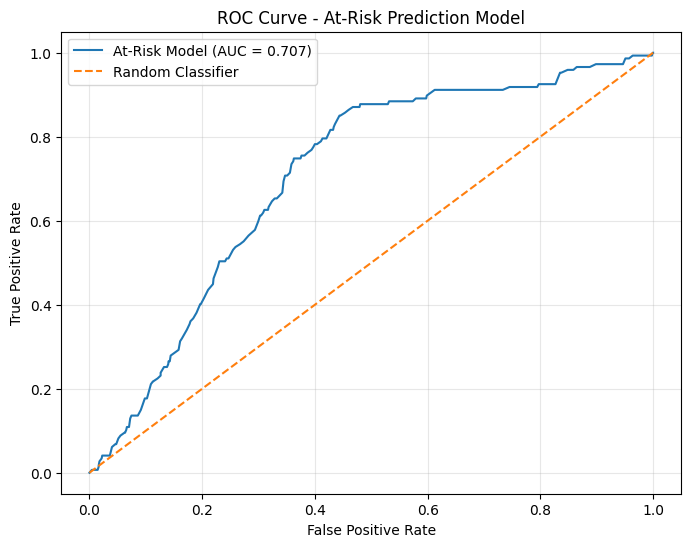

In [115]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"At-Risk Model (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - At-Risk Prediction Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [116]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Calculate Precision-Recall AUC
pr_auc = average_precision_score(
    y_test_risk,
    y_prob_risk
)

# Precision-Recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test_risk,
    y_prob_risk
)

print("=" * 50)
print("Precision-Recall AUC - At-Risk Model")
print("=" * 50)

print(f"PR-AUC Score: {pr_auc:.4f}")

Precision-Recall AUC - At-Risk Model
PR-AUC Score: 0.1263


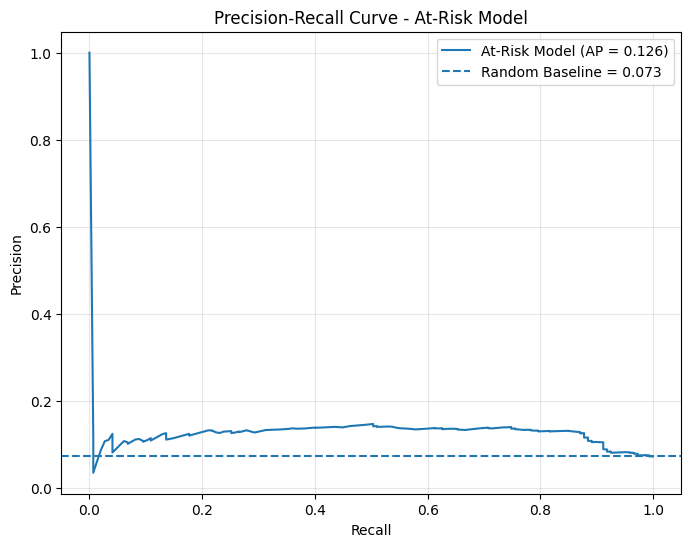

In [117]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"At-Risk Model (AP = {pr_auc:.3f})"
)

# Baseline = proportion of positive class
baseline = y_test_risk.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - At-Risk Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [118]:
# ==========================================
# 41.2 — Final At-Risk Model Summary
# ==========================================

final_risk_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Specificity",
        "ROC-AUC",
        "PR-AUC",
        "Threshold"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_specificity,
        roc_auc,
        pr_auc,
        FINAL_RISK_THRESHOLD
    ]
})

print("=" * 55)
print("FINAL AT-RISK MODEL EVALUATION")
print("=" * 55)

print(
    final_risk_summary.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

FINAL AT-RISK MODEL EVALUATION
     Metric  Score
   Accuracy 0.6570
  Precision 0.1392
     Recall 0.7075
   F1 Score 0.2327
Specificity 0.6530
    ROC-AUC 0.7067
     PR-AUC 0.1263
  Threshold 0.6000


<Figure size 700x600 with 0 Axes>

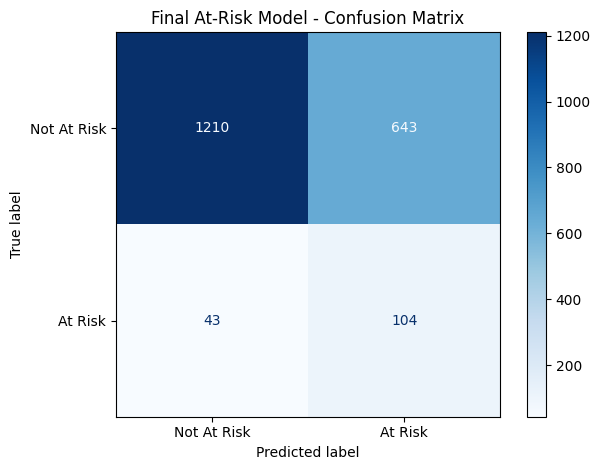

In [119]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final_risk,
    display_labels=["Not At Risk", "At Risk"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Final At-Risk Model - Confusion Matrix")
plt.tight_layout()
plt.show()

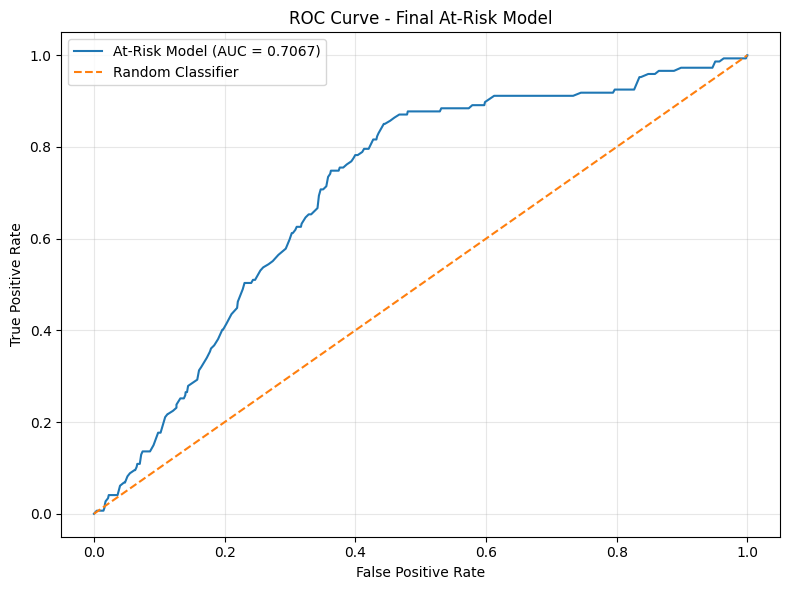

In [120]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(
    y_test_risk,
    y_prob_risk
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"At-Risk Model (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final At-Risk Model")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

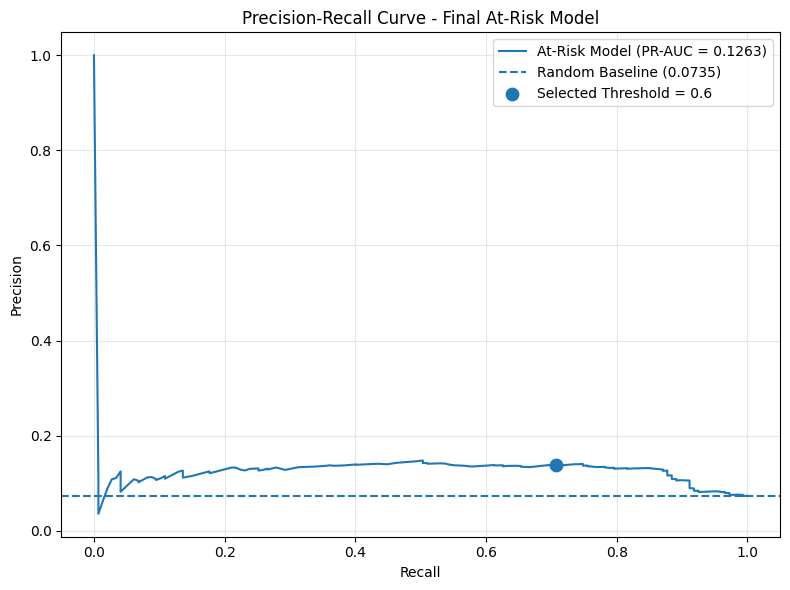

In [121]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate Precision-Recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test_risk,
    y_prob_risk
)

# Baseline = proportion of At-Risk students
baseline = y_test_risk.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"At-Risk Model (PR-AUC = {pr_auc:.4f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random Baseline ({baseline:.4f})"
)

# Mark selected threshold performance
plt.scatter(
    final_recall,
    final_precision,
    s=80,
    label=f"Selected Threshold = {FINAL_RISK_THRESHOLD}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final At-Risk Model")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
# ==========================================
# 41.6 — Final Performance Table
# ==========================================

final_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Specificity",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_specificity,
        roc_auc,
        pr_auc
    ]
})

final_performance["Percentage"] = (
    final_performance["Value"] * 100
).round(2)

print("=" * 60)
print("FINAL AT-RISK MODEL PERFORMANCE")
print("=" * 60)

print(
    final_performance.to_string(
        index=False
    )
)

FINAL AT-RISK MODEL PERFORMANCE
     Metric    Value  Percentage
   Accuracy 0.657000       65.70
  Precision 0.139224       13.92
     Recall 0.707483       70.75
   F1 Score 0.232662       23.27
Specificity 0.652995       65.30
    ROC-AUC 0.706732       70.67
     PR-AUC 0.126295       12.63


In [123]:
print("Available model prediction variables:")
print([
    name for name in globals()
    if "pred" in name.lower()
])

print("\nAvailable accuracy variables:")
print([
    name for name in globals()
    if "accuracy" in name.lower()
])

Available model prediction variables:
['y_pred_logistic', 'y_pred_tree', 'y_pred_rf', 'y_pred_gradient', 'y_pred_risk', 'y_pred_threshold', 'y_pred_risk_060', 'y_pred_risk_clean', 'y_pred_risk_clean_best', 'y_pred_final_risk']

Available accuracy variables:
['accuracy_score', 'accuracy_logistic', 'accuracy_tree', 'accuracy_rf', 'accuracy_gradient', 'risk_accuracy', 'accuracy', 'final_accuracy']


In [124]:
print("\nExisting model objects:")
print([
    name for name in globals()
    if "model" in name.lower()
])


Existing model objects:
['logistic_model', 'gradient_model', 'model_results', 'risk_model', 'risk_model_clean']


In [125]:
print("Model Results:")
print(model_results)

Model Results:
                 Model  Accuracy (%)
0  Logistic Regression         24.90
1        Decision Tree         20.40
2        Random Forest         28.95
3    Gradient Boosting         56.35


In [126]:
print("\nModel Results Columns:")
print(model_results.columns.tolist())


Model Results Columns:
['Model', 'Accuracy (%)']


In [127]:
print("\n5-Class Accuracies:")
print(f"Logistic Regression : {accuracy_logistic:.4f}")
print(f"Decision Tree       : {accuracy_tree:.4f}")
print(f"Random Forest       : {accuracy_rf:.4f}")
print(f"Gradient Boosting   : {accuracy_gradient:.4f}")


5-Class Accuracies:
Logistic Regression : 0.2490
Decision Tree       : 0.2040
Random Forest       : 0.2895
Gradient Boosting   : 0.5635


In [128]:
# ==========================================
# 41.8 — Final Model Comparison
# ==========================================

final_model_comparison = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "At-Risk Model"
    ],
    "Prediction Task": [
        "5-Class Grade Prediction",
        "Binary At-Risk Prediction"
    ],
    "Accuracy": [
        accuracy_gradient,
        final_accuracy
    ],
    "Precision": [
        precision_score(
            y_test,
            y_pred_gradient,
            average="weighted",
            zero_division=0
        ),
        final_precision
    ],
    "Recall": [
        recall_score(
            y_test,
            y_pred_gradient,
            average="weighted",
            zero_division=0
        ),
        final_recall
    ],
    "F1 Score": [
        f1_score(
            y_test,
            y_pred_gradient,
            average="weighted",
            zero_division=0
        ),
        final_f1
    ]
})

print("=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)

print(
    final_model_comparison.round(4).to_string(index=False)
)

FINAL MODEL COMPARISON
            Model           Prediction Task  Accuracy  Precision  Recall  F1 Score
Gradient Boosting  5-Class Grade Prediction    0.5635     0.4268  0.5635    0.4284
    At-Risk Model Binary At-Risk Prediction    0.6570     0.1392  0.7075    0.2327


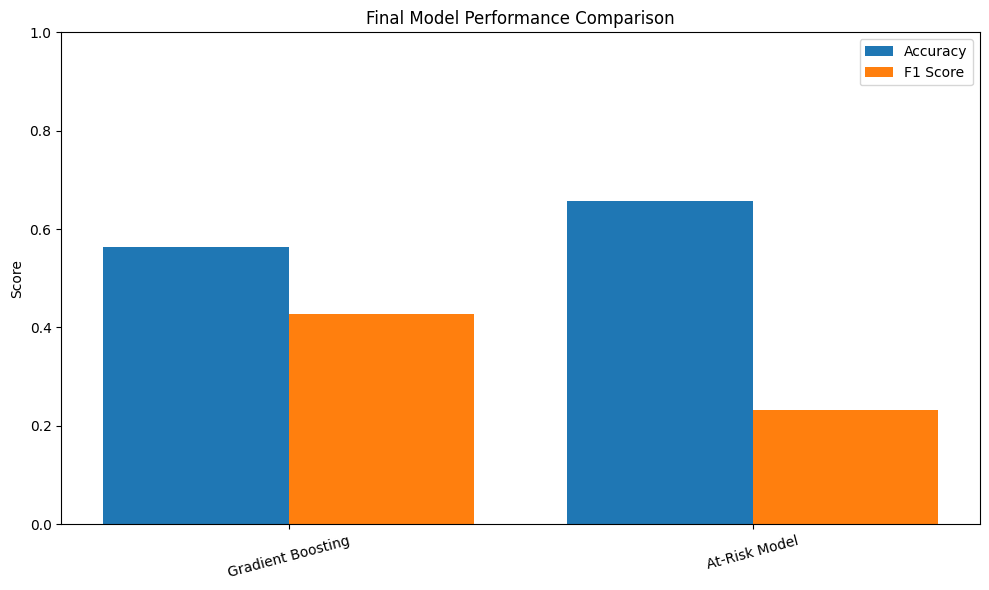

In [129]:
import matplotlib.pyplot as plt

models = final_model_comparison["Model"]
accuracies = final_model_comparison["Accuracy"]
f1_scores = final_model_comparison["F1 Score"]

plt.figure(figsize=(10, 6))

x = range(len(models))

plt.bar(
    [i - 0.2 for i in x],
    accuracies,
    width=0.4,
    label="Accuracy"
)

plt.bar(
    [i + 0.2 for i in x],
    f1_scores,
    width=0.4,
    label="F1 Score"
)

plt.xticks(
    list(x),
    models,
    rotation=15
)

plt.ylabel("Score")
plt.title("Final Model Performance Comparison")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

In [130]:
# ==========================================
# 41.10 — Gradient Boosting Feature Importance
# ==========================================

feature_importance_5class = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gradient_model.feature_importances_
})

feature_importance_5class = feature_importance_5class.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 60)
print("GRADIENT BOOSTING - FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance_5class.to_string(index=False)
)

GRADIENT BOOSTING - FEATURE IMPORTANCE
                                      Feature  Importance
                                  gender_male    0.402974
                                gender_female    0.353699
                      test_preparation_course    0.035706
                                        lunch    0.031097
  parental_level_of_education_master's degree    0.022197
                       race_ethnicity_group E    0.020662
      parental_level_of_education_high school    0.018248
                       race_ethnicity_group A    0.016492
     parental_level_of_education_some college    0.013938
parental_level_of_education_bachelor's degree    0.012170
                       race_ethnicity_group C    0.011931
                       race_ethnicity_group B    0.011326
                       race_ethnicity_group D    0.010372
 parental_level_of_education_some high school    0.009717
                                  gender_Girl    0.009577
                             race

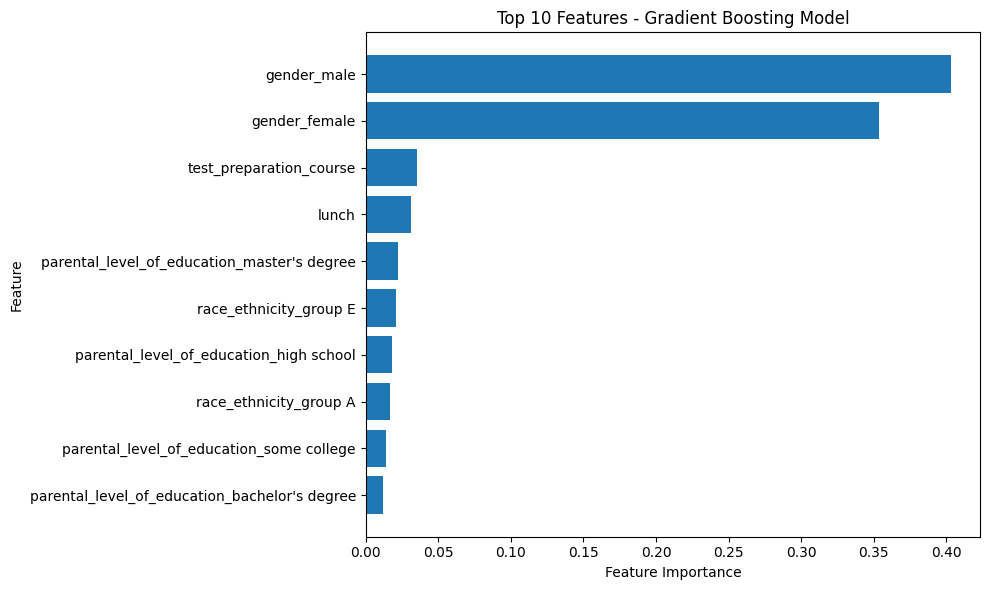

In [131]:
top_features_5class = feature_importance_5class.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_5class["Feature"][::-1],
    top_features_5class["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Gradient Boosting Model")

plt.tight_layout()
plt.show()

In [132]:
# ==========================================
# 41.10 — Gradient Boosting Feature Importance
# ==========================================

feature_importance_5class = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gradient_model.feature_importances_
})

feature_importance_5class = feature_importance_5class.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 60)
print("GRADIENT BOOSTING - FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance_5class.to_string(index=False))

GRADIENT BOOSTING - FEATURE IMPORTANCE
                                      Feature  Importance
                                  gender_male    0.402974
                                gender_female    0.353699
                      test_preparation_course    0.035706
                                        lunch    0.031097
  parental_level_of_education_master's degree    0.022197
                       race_ethnicity_group E    0.020662
      parental_level_of_education_high school    0.018248
                       race_ethnicity_group A    0.016492
     parental_level_of_education_some college    0.013938
parental_level_of_education_bachelor's degree    0.012170
                       race_ethnicity_group C    0.011931
                       race_ethnicity_group B    0.011326
                       race_ethnicity_group D    0.010372
 parental_level_of_education_some high school    0.009717
                                  gender_Girl    0.009577
                             race

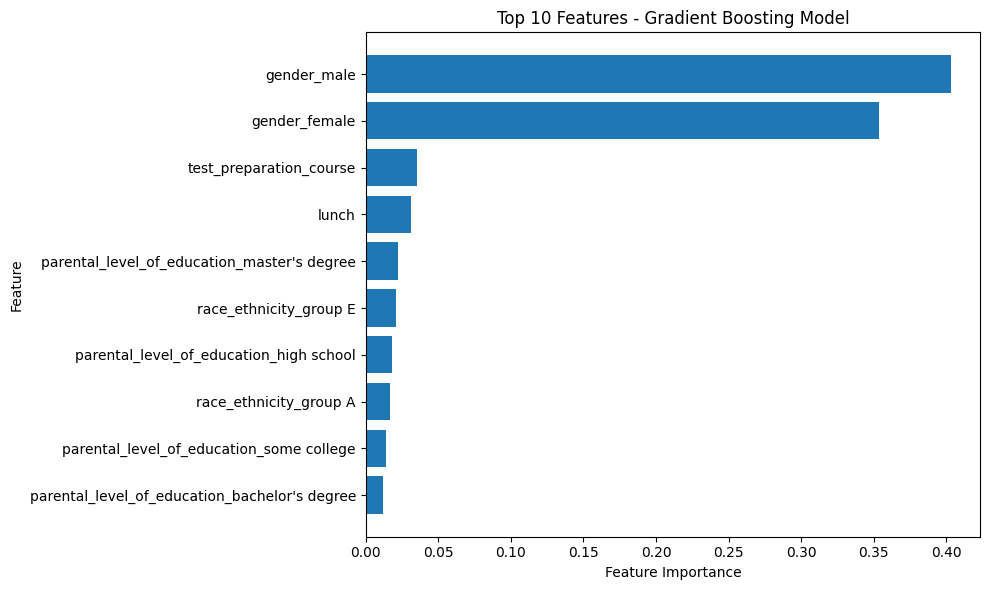

In [133]:
top_features_5class = feature_importance_5class.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features_5class["Feature"][::-1],
    top_features_5class["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Gradient Boosting Model")

plt.tight_layout()
plt.show()

In [134]:
# ==========================================
# 41.11 — At-Risk Feature Importance
# ==========================================

risk_feature_importance = pd.DataFrame({
    "Feature": X_train_risk.columns,
    "Importance": risk_model.feature_importances_
})

risk_feature_importance = risk_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 60)
print("AT-RISK MODEL - FEATURE IMPORTANCE")
print("=" * 60)

print(risk_feature_importance.to_string(index=False))

AT-RISK MODEL - FEATURE IMPORTANCE
                                      Feature  Importance
                                  gender_male    0.857860
                                        lunch    0.021140
                       race_ethnicity_group A    0.020776
                      test_preparation_course    0.020396
  parental_level_of_education_master's degree    0.017201
                       race_ethnicity_group B    0.011881
 parental_level_of_education_some high school    0.011753
                       race_ethnicity_group E    0.010301
     parental_level_of_education_some college    0.007280
parental_level_of_education_bachelor's degree    0.006818
                       race_ethnicity_group C    0.005520
                       race_ethnicity_group D    0.003322
      parental_level_of_education_high school    0.001819
                     race_ethnicity_group C\n    0.001791
                                gender_female    0.000987
                             race_eth

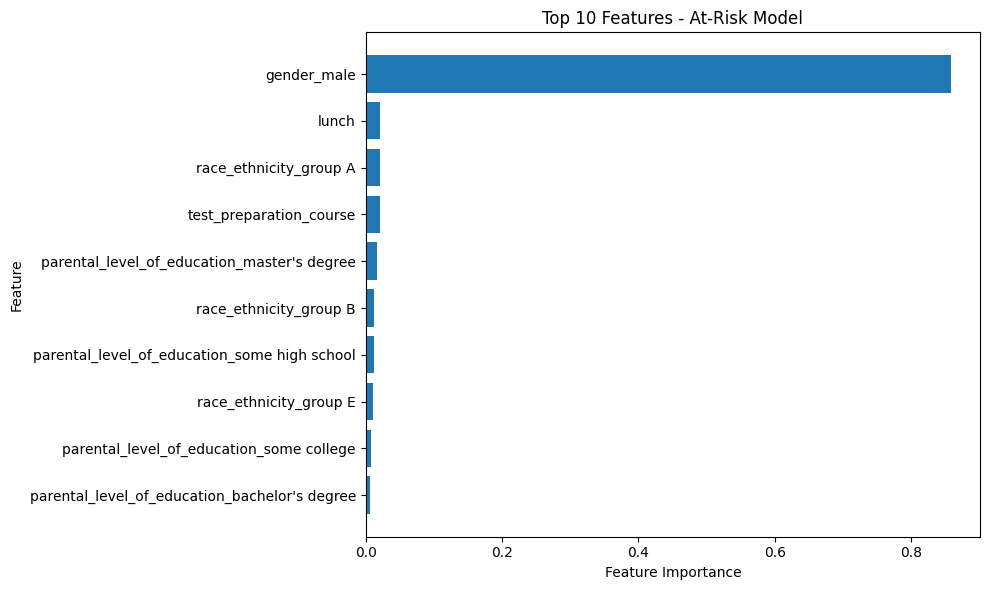

In [135]:
top_risk_features = risk_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_risk_features["Feature"][::-1],
    top_risk_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - At-Risk Model")

plt.tight_layout()
plt.show()

In [136]:
print("At-Risk Model Features:")
print(X_train_risk.columns.tolist())

At-Risk Model Features:
['lunch', 'test_preparation_course', 'gender_Girl', 'gender_\\tmale', 'gender_female', 'gender_male', 'race_ethnicity_B', 'race_ethnicity_C', 'race_ethnicity_D', 'race_ethnicity_E', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group C\\n', 'race_ethnicity_group D', 'race_ethnicity_group E', "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school']


In [137]:
# ==========================================
# 41.12 — Sample Student
# ==========================================

sample_student = pd.DataFrame({
    "lunch": [0],
    "test_preparation_course": [0],
    "gender_male": [1],
    "race_ethnicity_B": [0],
    "race_ethnicity_C": [1],
    "race_ethnicity_D": [0],
    "race_ethnicity_E": [0],
    "parental_level_of_education_bachelor's degree": [0],
    "parental_level_of_education_high school": [1],
    "parental_level_of_education_master's degree": [0],
    "parental_level_of_education_some college": [0],
    "parental_level_of_education_some high school": [0]
})

# Make sure columns are in exactly the same order
sample_student = sample_student.reindex(
    columns=X_train_risk.columns,
    fill_value=0
)

print(sample_student)

   lunch  test_preparation_course  gender_Girl  gender_\tmale  gender_female  \
0      0                        0            0              0              0   

   gender_male  race_ethnicity_B  race_ethnicity_C  race_ethnicity_D  \
0            1                 0                 1                 0   

   race_ethnicity_E  ...  race_ethnicity_group B  race_ethnicity_group C  \
0                 0  ...                       0                       0   

   race_ethnicity_group C\n  race_ethnicity_group D  race_ethnicity_group E  \
0                         0                       0                       0   

   parental_level_of_education_bachelor's degree  \
0                                              0   

   parental_level_of_education_high school  \
0                                        1   

   parental_level_of_education_master's degree  \
0                                            0   

   parental_level_of_education_some college  \
0                                   

In [138]:
# Probability of At-Risk
sample_probability = risk_model.predict_proba(
    sample_student
)[:, 1][0]

# Final threshold
sample_prediction = int(
    sample_probability >= FINAL_RISK_THRESHOLD
)

print("=" * 50)
print("STUDENT AT-RISK PREDICTION")
print("=" * 50)

print(f"At-Risk Probability: {sample_probability:.2%}")

if sample_prediction == 1:
    print("Prediction: AT RISK")
else:
    print("Prediction: NOT AT RISK")

STUDENT AT-RISK PREDICTION
At-Risk Probability: 54.33%
Prediction: NOT AT RISK


In [139]:
print("5-Class Model Features:")
print(X_train.columns.tolist())

5-Class Model Features:
['lunch', 'test_preparation_course', 'gender_Girl', 'gender_\\tmale', 'gender_female', 'gender_male', 'race_ethnicity_B', 'race_ethnicity_C', 'race_ethnicity_D', 'race_ethnicity_E', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group C\\n', 'race_ethnicity_group D', 'race_ethnicity_group E', "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school']


In [140]:
sample_grade_student = X_test.iloc[[0]].copy()

print("Sample Student Input:")
print(sample_grade_student)

Sample Student Input:
      lunch  test_preparation_course  gender_Girl  gender_\tmale  \
5188    1.0                      0.0        False          False   

      gender_female  gender_male  race_ethnicity_B  race_ethnicity_C  \
5188           True        False             False             False   

      race_ethnicity_D  race_ethnicity_E  ...  race_ethnicity_group B  \
5188             False             False  ...                   False   

      race_ethnicity_group C  race_ethnicity_group C\n  \
5188                   False                     False   

      race_ethnicity_group D  race_ethnicity_group E  \
5188                    True                   False   

      parental_level_of_education_bachelor's degree  \
5188                                          False   

      parental_level_of_education_high school  \
5188                                    False   

      parental_level_of_education_master's degree  \
5188                                        False   

  

In [141]:
sample_grade_prediction = gradient_model.predict(
    sample_grade_student
)[0]

print("=" * 50)
print("STUDENT GRADE PREDICTION")
print("=" * 50)

print("Predicted Grade:", sample_grade_prediction)

STUDENT GRADE PREDICTION
Predicted Grade: 1


In [142]:
import numpy as np

print("Unique y_train values:")
print(np.unique(y_train))

print("\nUnique y_test values:")
print(np.unique(y_test))

print("\nOriginal grade values:")
print(df_clean["grade"].unique())

Unique y_train values:
[0 1 2 3 4]

Unique y_test values:
[0 1 2 3 4]

Original grade values:
['C' 'A' 'B' 'D' 'Fail']


In [143]:
print("\nLabel Encoder Classes:")

try:
    print(label_encoder.classes_)
except NameError:
    print("label_encoder variable not found")


Label Encoder Classes:
['A' 'B' 'C' 'D' 'Fail']


In [144]:
# ==========================================
# 41.13.2 — Human-Readable Grade Prediction
# ==========================================

sample_grade_prediction = gradient_model.predict(
    sample_grade_student
)[0]

predicted_grade_label = label_encoder.inverse_transform(
    [sample_grade_prediction]
)[0]

print("=" * 50)
print("STUDENT GRADE PREDICTION")
print("=" * 50)

print("Encoded Prediction :", sample_grade_prediction)
print("Predicted Grade     :", predicted_grade_label)

STUDENT GRADE PREDICTION
Encoded Prediction : 1
Predicted Grade     : B


In [145]:
sample_grade_student = X_test.iloc[[0]]

In [146]:
print("=" * 65)
print("FINAL 5-CLASS GRADIENT BOOSTING MODEL")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred_gradient,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

print("\nConfusion Matrix:")

cm_5class = confusion_matrix(
    y_test,
    y_pred_gradient
)

print(cm_5class)

FINAL 5-CLASS GRADIENT BOOSTING MODEL
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       181
           B       0.57      0.97      0.72      1132
           C       0.39      0.04      0.08       540
           D       0.00      0.00      0.00       134
        Fail       0.00      0.00      0.00        13

    accuracy                           0.56      2000
   macro avg       0.19      0.20      0.16      2000
weighted avg       0.43      0.56      0.43      2000


Confusion Matrix:
[[   0  179    2    0    0]
 [   0 1103   29    0    0]
 [   1  515   24    0    0]
 [   0  127    7    0    0]
 [   0   13    0    0    0]]


<Figure size 800x700 with 0 Axes>

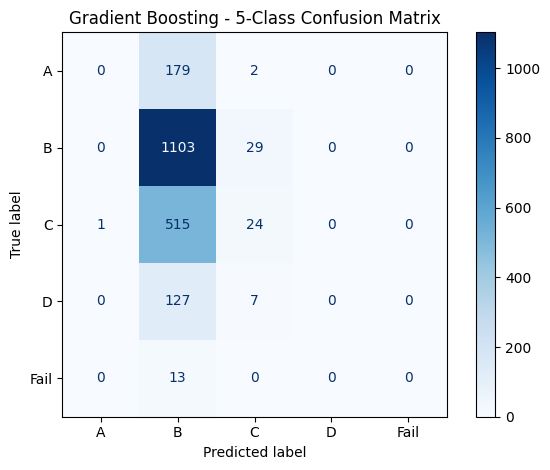

In [147]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_5class,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Gradient Boosting - 5-Class Confusion Matrix")
plt.tight_layout()
plt.show()

In [148]:
# ==========================================
# 41.16 — Final Project Results
# ==========================================

grade_precision = precision_score(
    y_test,
    y_pred_gradient,
    average="weighted",
    zero_division=0
)

grade_recall = recall_score(
    y_test,
    y_pred_gradient,
    average="weighted",
    zero_division=0
)

grade_f1 = f1_score(
    y_test,
    y_pred_gradient,
    average="weighted",
    zero_division=0
)

project_results = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "At-Risk Model"
    ],
    "Task": [
        "5-Class Grade Prediction",
        "Binary At-Risk Prediction"
    ],
    "Accuracy": [
        accuracy_gradient,
        final_accuracy
    ],
    "Precision": [
        grade_precision,
        final_precision
    ],
    "Recall": [
        grade_recall,
        final_recall
    ],
    "F1 Score": [
        grade_f1,
        final_f1
    ]
})

print("=" * 75)
print("FINAL PROJECT RESULTS")
print("=" * 75)

print(project_results.round(4).to_string(index=False))

FINAL PROJECT RESULTS
            Model                      Task  Accuracy  Precision  Recall  F1 Score
Gradient Boosting  5-Class Grade Prediction    0.5635     0.4268  0.5635    0.4284
    At-Risk Model Binary At-Risk Prediction    0.6570     0.1392  0.7075    0.2327


In [149]:
import joblib

# Save final 5-class model
joblib.dump(
    gradient_model,
    "final_grade_prediction_model.pkl"
)

# Save final At-Risk model
joblib.dump(
    risk_model,
    "final_at_risk_model.pkl"
)

# Save Label Encoder
joblib.dump(
    label_encoder,
    "grade_label_encoder.pkl"
)

# Save At-Risk threshold
joblib.dump(
    FINAL_RISK_THRESHOLD,
    "at_risk_threshold.pkl"
)

print("All final model files saved successfully!")

All final model files saved successfully!


In [150]:
# ==========================================
# 41.18 — Verify Saved Models
# ==========================================

loaded_grade_model = joblib.load(
    "final_grade_prediction_model.pkl"
)

loaded_risk_model = joblib.load(
    "final_at_risk_model.pkl"
)

loaded_label_encoder = joblib.load(
    "grade_label_encoder.pkl"
)

loaded_threshold = joblib.load(
    "at_risk_threshold.pkl"
)

print("Grade Model :", type(loaded_grade_model))
print("Risk Model  :", type(loaded_risk_model))
print("Encoder     :", type(loaded_label_encoder))
print("Threshold   :", loaded_threshold)

Grade Model : <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Risk Model  : <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Encoder     : <class 'sklearn.preprocessing._label.LabelEncoder'>
Threshold   : 0.6


In [151]:
# ==========================================
# 41.19 — Final Model Verification
# ==========================================

import numpy as np

# -----------------------------
# 1. Verify Grade Model
# -----------------------------

original_grade_pred = gradient_model.predict(X_test)

loaded_grade_pred = loaded_grade_model.predict(X_test)

grade_match = np.array_equal(
    original_grade_pred,
    loaded_grade_pred
)


# -----------------------------
# 2. Verify At-Risk Model
# -----------------------------

original_risk_prob = risk_model.predict_proba(
    X_test_risk
)[:, 1]

loaded_risk_prob = loaded_risk_model.predict_proba(
    X_test_risk
)[:, 1]

risk_match = np.allclose(
    original_risk_prob,
    loaded_risk_prob
)


# -----------------------------
# 3. Verify Label Encoder
# -----------------------------

original_classes = label_encoder.classes_
loaded_classes = loaded_label_encoder.classes_

encoder_match = np.array_equal(
    original_classes,
    loaded_classes
)


# -----------------------------
# 4. Verify Threshold
# -----------------------------

threshold_match = (
    FINAL_RISK_THRESHOLD == loaded_threshold
)


# -----------------------------
# Final Verification
# -----------------------------

print("=" * 65)
print("FINAL MODEL VERIFICATION")
print("=" * 65)

print(
    "Grade predictions identical :",
    grade_match
)

print(
    "Risk probabilities identical:",
    risk_match
)

print(
    "Label encoder identical     :",
    encoder_match
)

print(
    "Threshold identical         :",
    threshold_match
)

if (
    grade_match
    and risk_match
    and encoder_match
    and threshold_match
):
    print("\n✓ ALL FINAL MODELS VERIFIED SUCCESSFULLY!")
else:
    print("\n⚠ Verification requires attention.")

FINAL MODEL VERIFICATION
Grade predictions identical : True
Risk probabilities identical: True
Label encoder identical     : True
Threshold identical         : True

✓ ALL FINAL MODELS VERIFIED SUCCESSFULLY!


In [152]:
# ==========================================
# 41.20 — FINAL PROJECT SUMMARY
# ==========================================

print("=" * 75)
print("FINAL PROJECT SUMMARY")
print("=" * 75)

print("\nDATASET")
print("-" * 40)
print("Total Students:", len(df_clean))
print("At-Risk Students:", int(y_risk_clean.sum()))
print("Not At-Risk Students:", int((y_risk_clean == 0).sum()))

print("\n5-CLASS GRADE MODEL")
print("-" * 40)
print("Model: Gradient Boosting")
print(f"Accuracy : {accuracy_gradient:.2%}")
print(f"Precision: {grade_precision:.2%}")
print(f"Recall   : {grade_recall:.2%}")
print(f"F1 Score : {grade_f1:.2%}")

print("\nAT-RISK MODEL")
print("-" * 40)
print("Model: Random Forest")
print(f"Threshold   : {FINAL_RISK_THRESHOLD}")
print(f"Accuracy    : {final_accuracy:.2%}")
print(f"Precision   : {final_precision:.2%}")
print(f"Recall      : {final_recall:.2%}")
print(f"F1 Score    : {final_f1:.2%}")
print(f"Specificity : {final_specificity:.2%}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")

print("\nAT-RISK CONFUSION MATRIX")
print("-" * 40)
print(cm_final_risk)

FINAL PROJECT SUMMARY

DATASET
----------------------------------------
Total Students: 9997
At-Risk Students: 733
Not At-Risk Students: 9264

5-CLASS GRADE MODEL
----------------------------------------
Model: Gradient Boosting
Accuracy : 56.35%
Precision: 42.68%
Recall   : 56.35%
F1 Score : 42.84%

AT-RISK MODEL
----------------------------------------
Model: Random Forest
Threshold   : 0.6
Accuracy    : 65.70%
Precision   : 13.92%
Recall      : 70.75%
F1 Score    : 23.27%
Specificity : 65.30%
ROC-AUC     : 0.7067
PR-AUC      : 0.1263

AT-RISK CONFUSION MATRIX
----------------------------------------
[[1210  643]
 [  43  104]]


# Final Model Results

## 5-Class Grade Prediction

**Best Model:** Gradient Boosting

| Metric | Score |
|---|---:|
| Accuracy | 56.35% |
| Weighted Precision | 42.68% |
| Weighted Recall | 56.35% |
| Weighted F1 Score | 42.84% |

## At-Risk Prediction

**Best Model:** Random Forest

| Metric | Score |
|---|---:|
| Threshold | 0.60 |
| Accuracy | 65.70% |
| Precision | 13.92% |
| Recall | 70.75% |
| F1 Score | 23.27% |
| Specificity | 65.30% |
| ROC-AUC | 0.7067 |
| PR-AUC | 0.1263 |

# Conclusion

This project developed a machine learning-based Student Performance Prediction and At-Risk Identification System using a dataset containing 9,997 student records.

Two major prediction tasks were performed. First, multiple machine learning algorithms were evaluated for five-class grade prediction, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Among these models, Gradient Boosting achieved the best performance with an accuracy of 56.35% and a weighted F1-score of 42.84%.

Second, a dedicated binary At-Risk classification model was developed to identify students who may require additional academic support. The final Random Forest model used a probability threshold of 0.60 and achieved 65.70% accuracy, 13.92% precision, 70.75% recall, 23.27% F1-score, 65.30% specificity, and a ROC-AUC of 0.7067.

The At-Risk model correctly identified 104 out of 147 genuinely At-Risk students. Its relatively high recall makes it useful as an early-warning system because the primary objective is to identify potentially struggling students. However, its low precision indicates that the model also generates a substantial number of false-positive alerts.

Therefore, the proposed system should be considered an early-warning and decision-support system rather than a definitive academic assessment tool. Overall, the project demonstrates how machine learning can be applied to student data to predict academic performance and support the early identification of students who may benefit from additional academic intervention.

# Limitations

1. The At-Risk dataset is highly imbalanced, with only 7.33% of students classified as At Risk.

2. The At-Risk model has relatively low precision, resulting in a considerable number of false-positive predictions.

3. The available dataset contains limited behavioral and longitudinal information about students.

4. Important factors such as attendance, assignment submission, previous semester performance, LMS activity, study habits, and continuous assessment may improve prediction if included.

5. Model performance may vary when applied to students from different institutions or populations.

6. The relatively modest performance of the five-class grade prediction model indicates that additional predictive features may be required for more reliable grade classification.

7. Predictions should not be used as the sole basis for academic decisions.

8. The system should support teachers and academic administrators rather than replace human judgment.

# Future Scope

The project can be further improved by incorporating additional student information such as attendance percentage, assignment submission history, previous semester marks, LMS activity, study patterns, internal assessment scores, and historical academic performance.

Advanced ensemble algorithms such as XGBoost, LightGBM, and stacking can be investigated to improve predictive performance.

Probability calibration and more sophisticated threshold optimization techniques can also be explored to improve the precision-recall trade-off of the At-Risk model.

Explainable AI techniques such as SHAP can be incorporated to explain why a particular student has been classified as At Risk.

The trained models can also be integrated into a web-based application or dashboard where teachers and administrators can enter student information and receive grade predictions and early At-Risk warnings.

Future versions could additionally include automated intervention recommendations, allowing the system to suggest appropriate academic support strategies for students identified as potentially At Risk.